In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss, zivot_andrews
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("../data/dataset_final/full_data.csv")
df["date"] = pd.to_datetime(df["month"], format = "%YM%m")
df.set_index("date", inplace = True)
df.index.freq = "MS"
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df = df.drop(columns='month')
df.head()

,diesel_price_(GHC/litre),lpg_ghs/kg,petrol_price_ghs/litre,brent_price_usd_per_barrel,usd/ghs_rate,consumer_price_index
date,,,,,,
2015-07-01,3.70,3.35,3.41,56.8,3.87,55.5
2015-08-01,3.46,3.35,2.76,48.2,3.92,55.1
2015-09-01,3.02,3.35,2.85,48.6,3.97,55.0
2015-10-01,2.85,3.35,2.77,48.1,3.99,56.5
2015-11-01,2.78,3.35,2.68,44.4,3.97,57.1


## **visualisation**

In [4]:
numeric_cols = df.select_dtypes(include="number").columns


In [5]:
import os

In [6]:
save_folder = "..\\documentation\\images"

os.makedirs(save_folder, exist_ok=True)

print(os.path.abspath(save_folder))

c:\Users\emman\Documents\RESOURCES\L400\SECOND_SEM\STAT450\documentation\images


## **trend analysis**

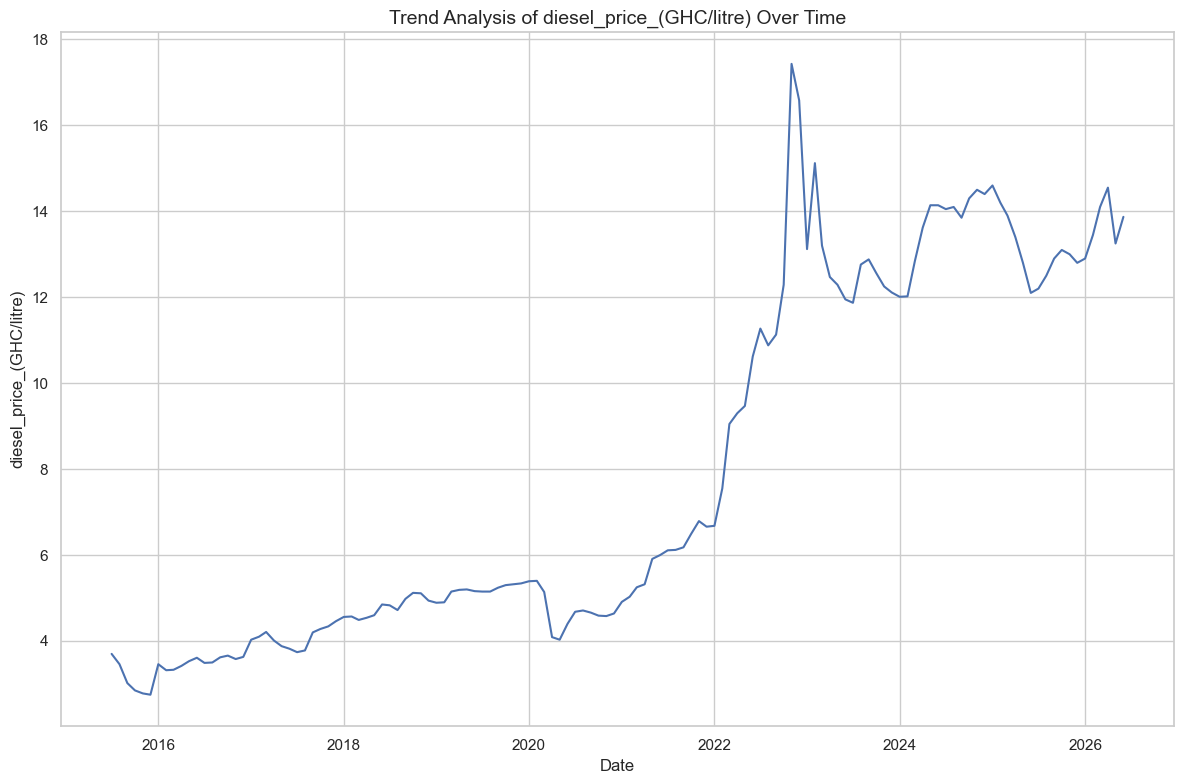

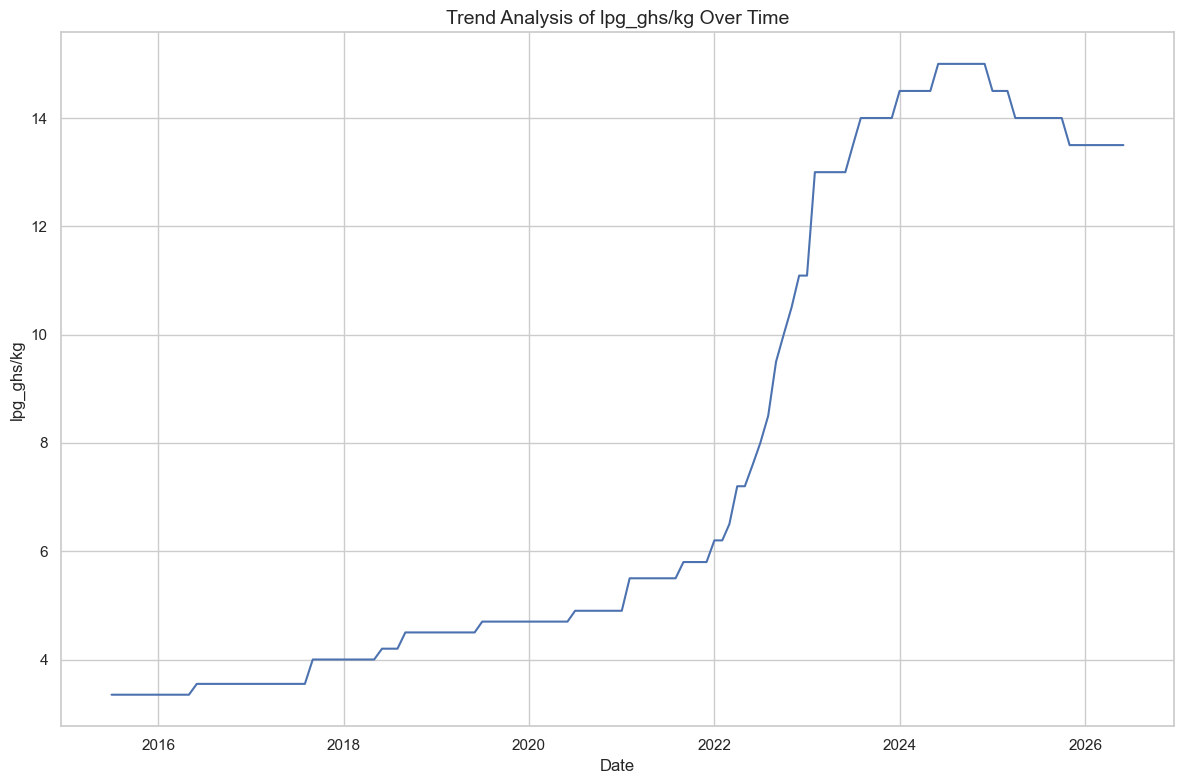

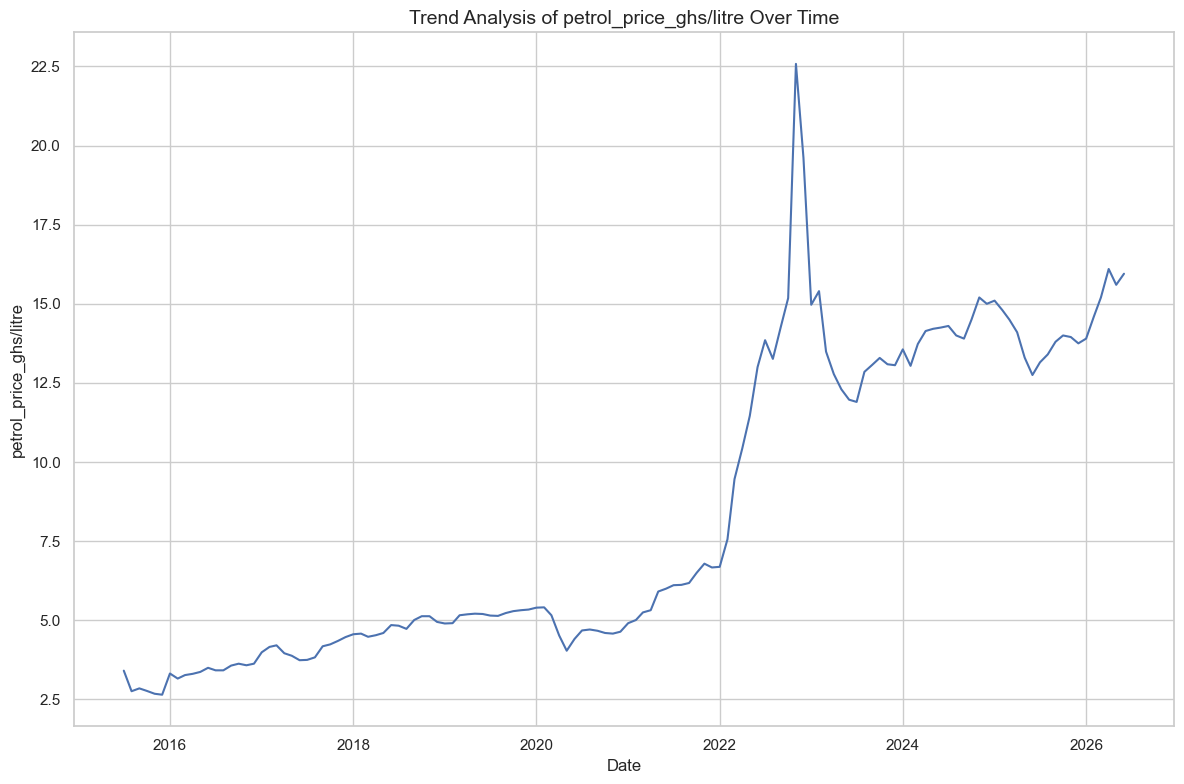

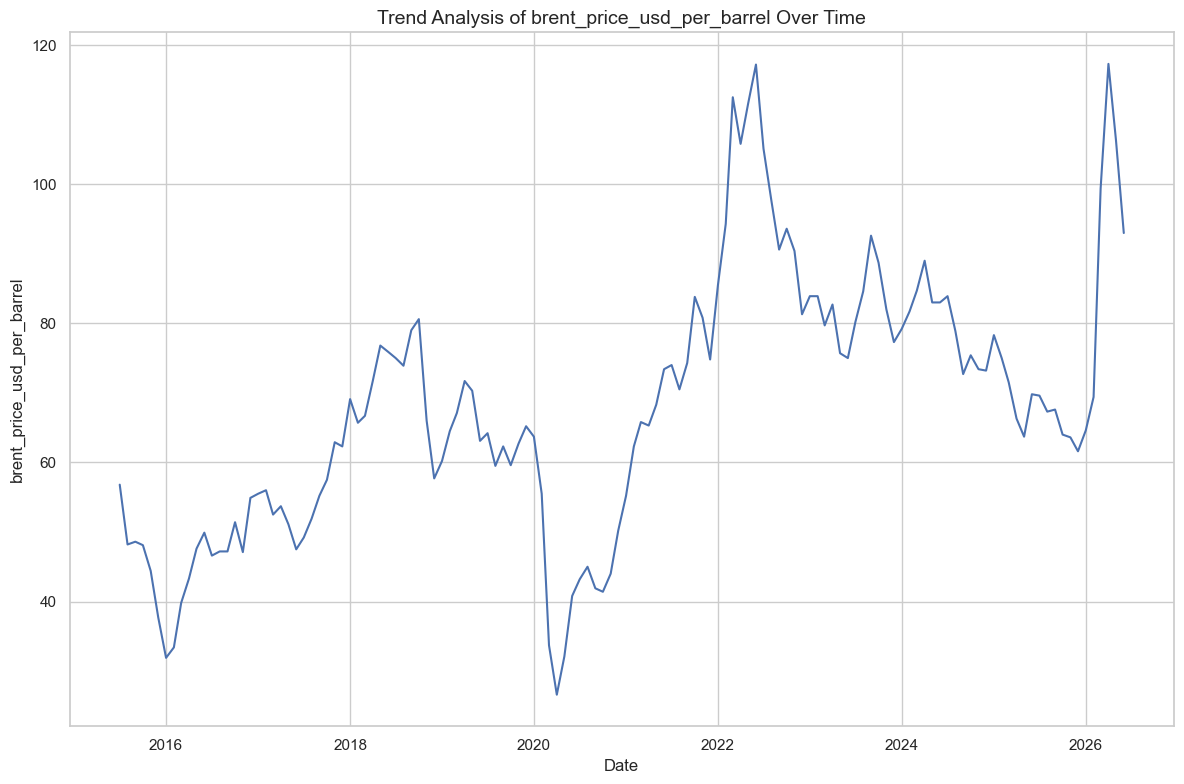

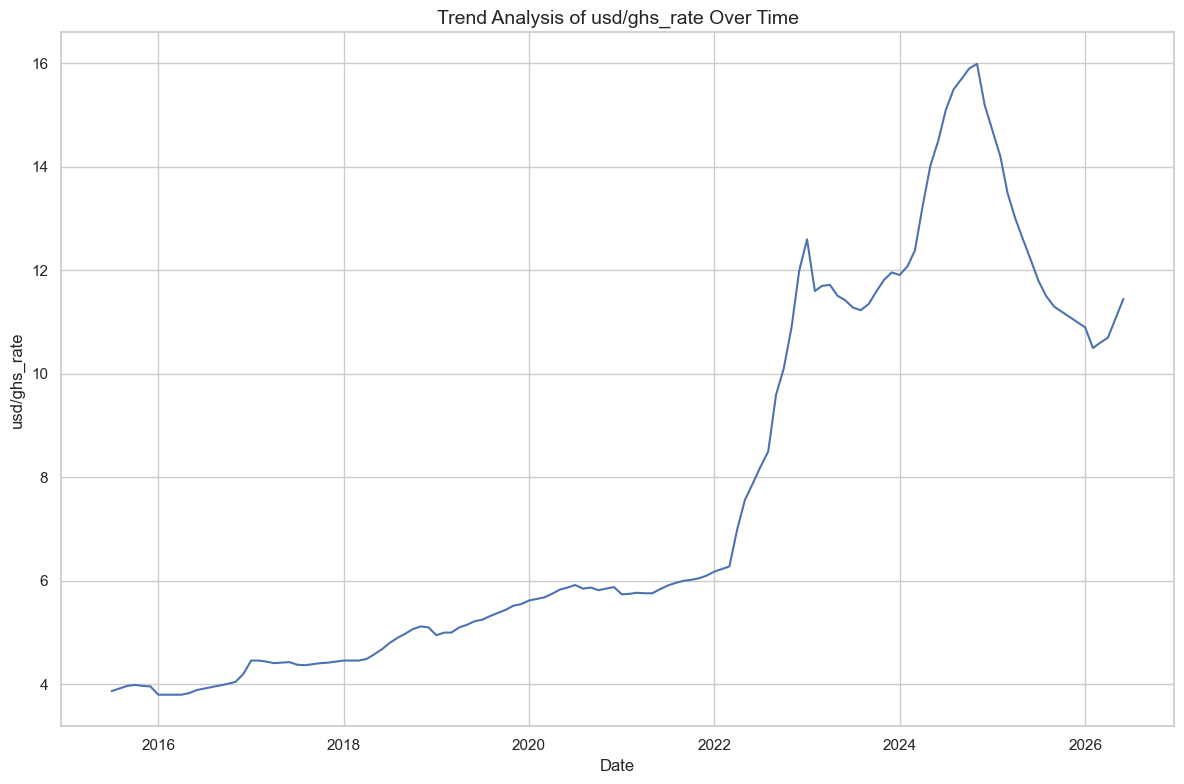

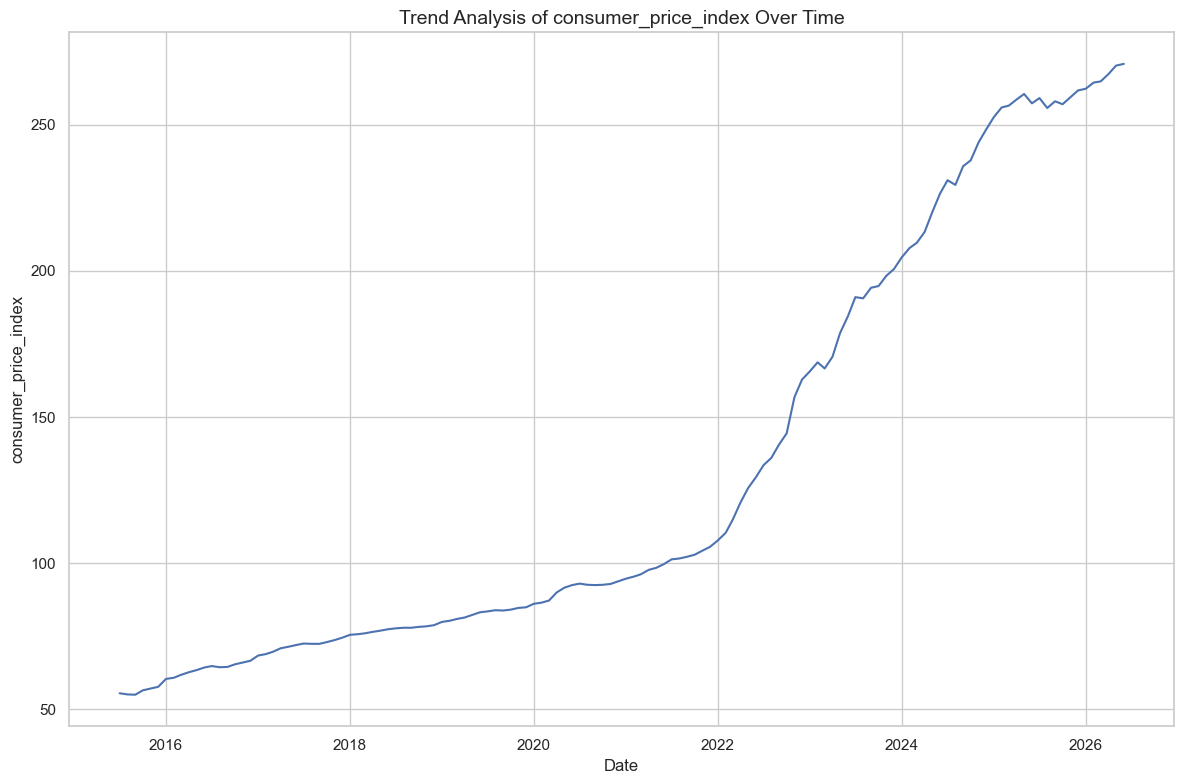

In [7]:
sns.set_theme(style = "whitegrid")
for col in numeric_cols:
    plt.figure(figsize=(12, 8))

    sns.lineplot(data=df, x=df.index, y=col)

    plt.title(f"Trend Analysis of {col} Over Time", fontsize=14)
    plt.xlabel("Date", fontsize = 12)
    plt.ylabel(col, fontsize = 12)

    plt.tight_layout()


    safe_col = col.replace("/", "_").replace("\\", "_")
    plt.savefig(
        os.path.join(save_folder, f"line_{safe_col}.jpeg"),
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

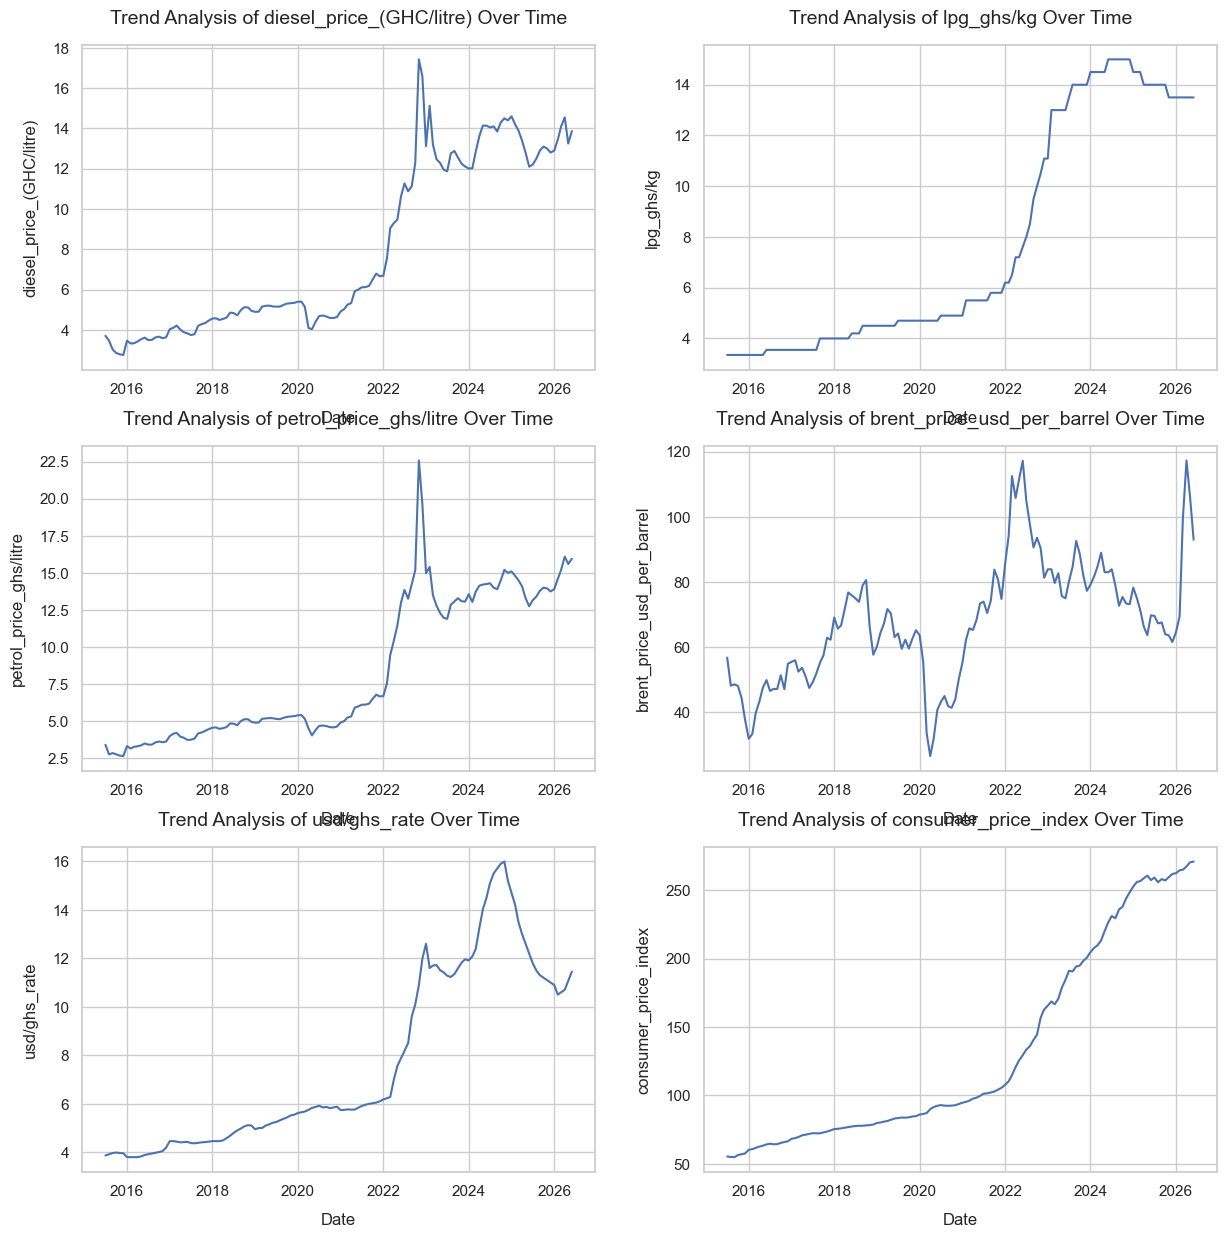

In [8]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(
    3, 
    2, 
    figsize = (15, 15), 
    constrained_layout = True
)
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.lineplot(data=df, x=df.index, y=col, ax=ax)
    ax.set_title(f"Trend Analysis of {col} Over Time", fontsize=14, pad=15)
    ax.set_xlabel("Date", fontsize=12, labelpad=10)
    ax.set_ylabel(col, fontsize=12, labelpad=10)
    
name = "Combined Trend Analysis of Commodities"
safe_col = name.replace("/", "_").replace("\\", "_").replace(" ", "_")

plt.savefig(
        os.path.join(save_folder, f"{safe_col}.jpeg"),
        dpi=600,
        bbox_inches="tight"
    )
plt.tight_layout()
plt.show()
plt.close(fig)

## **distribution**

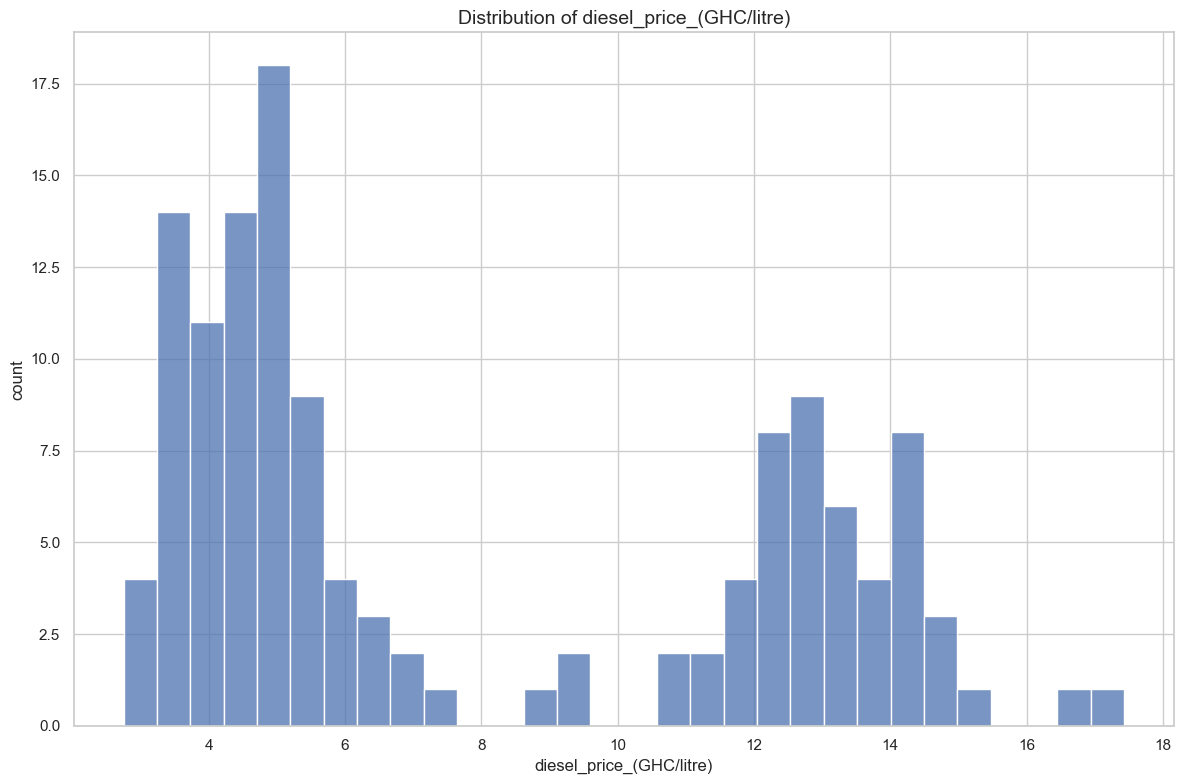

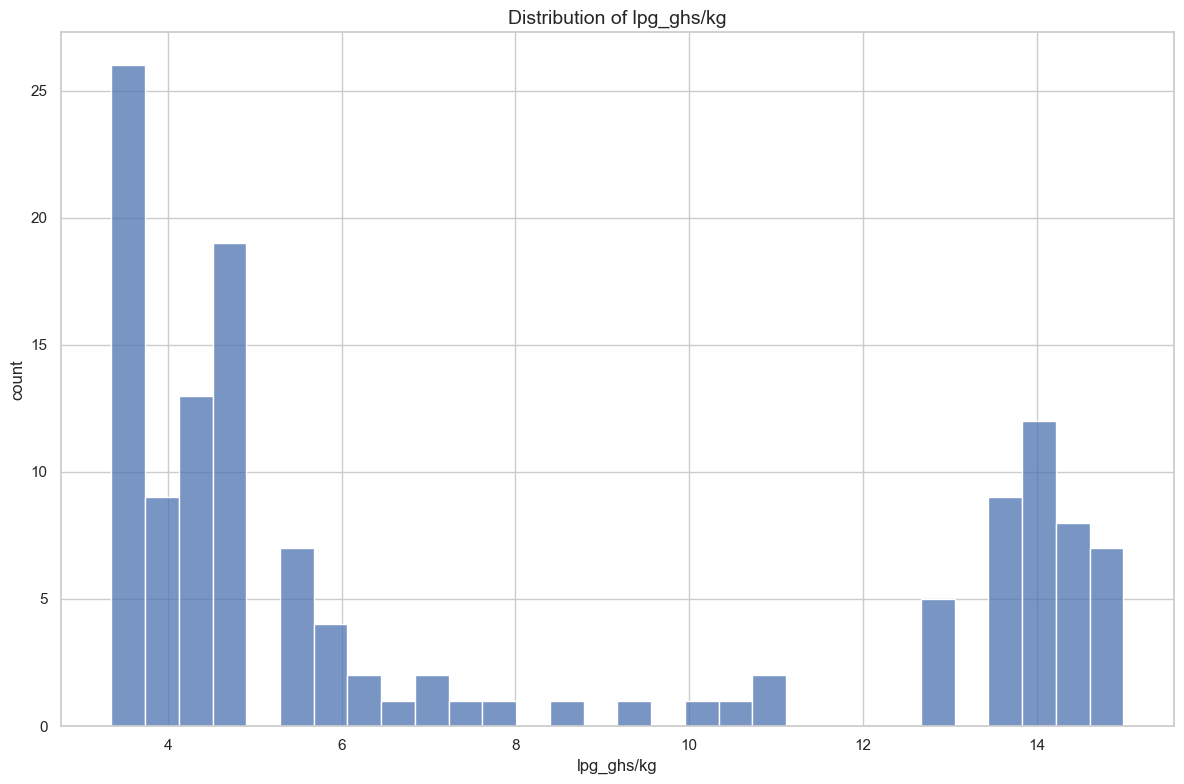

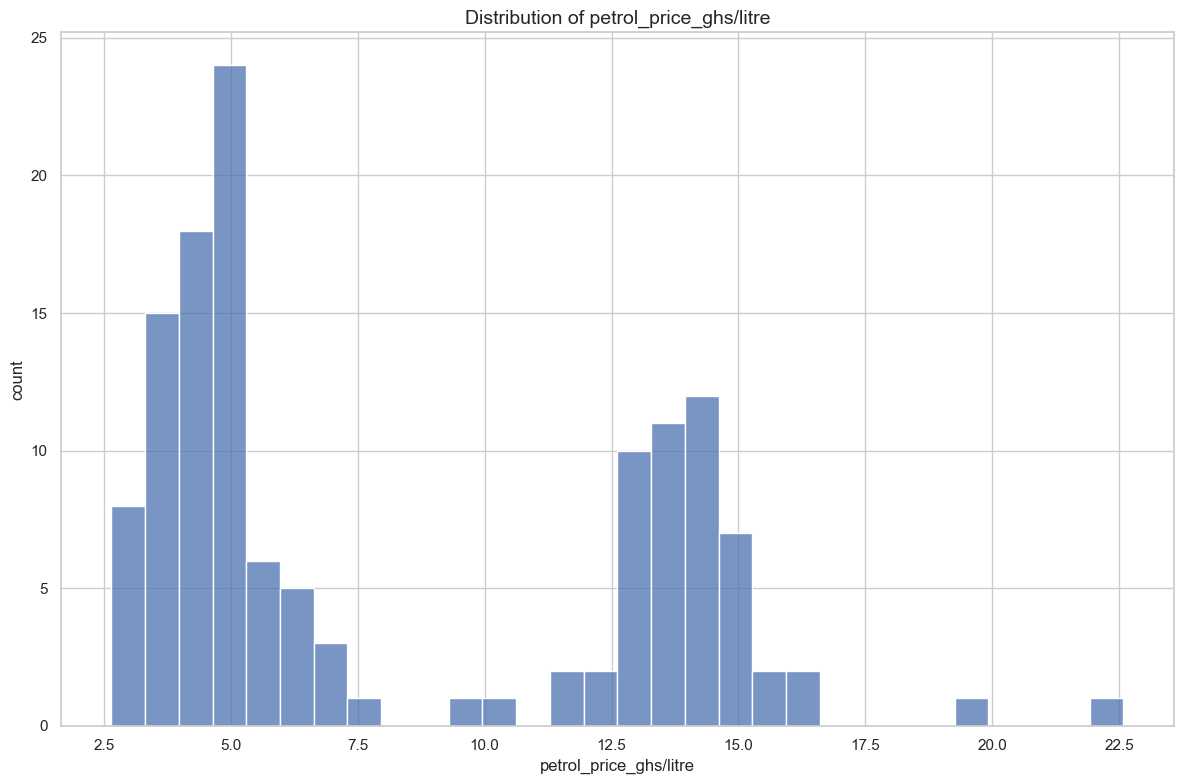

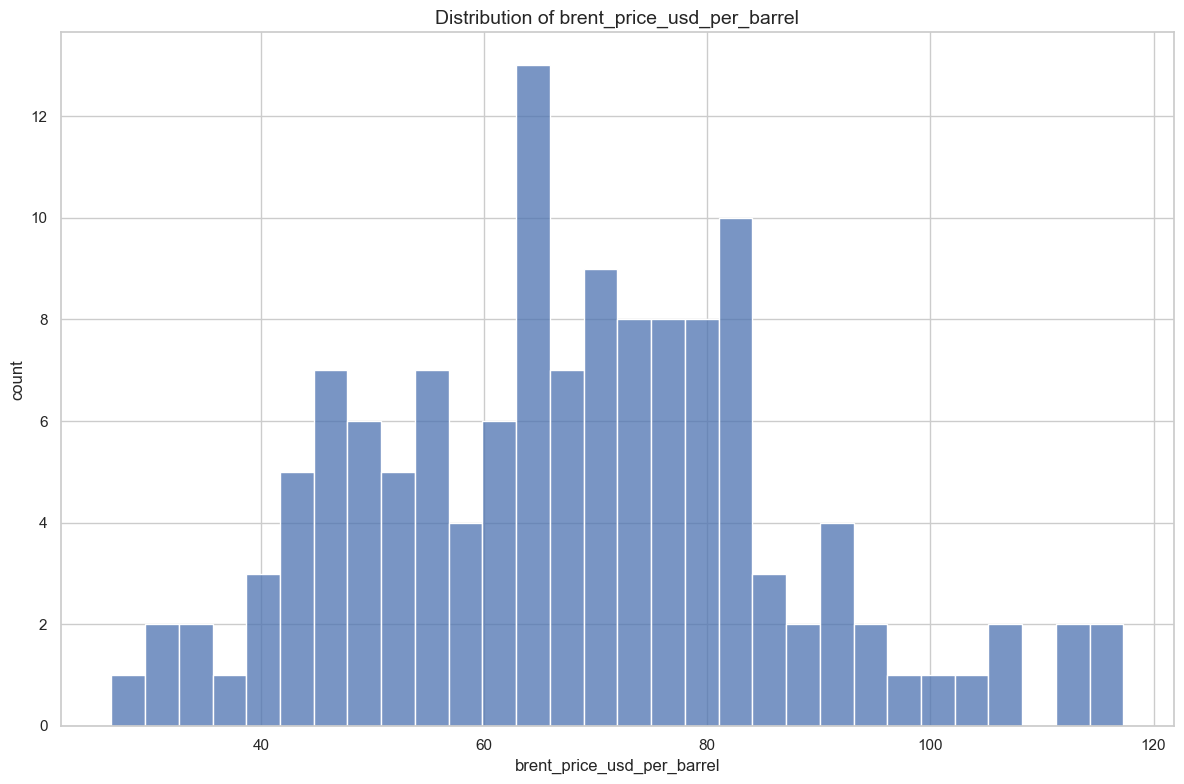

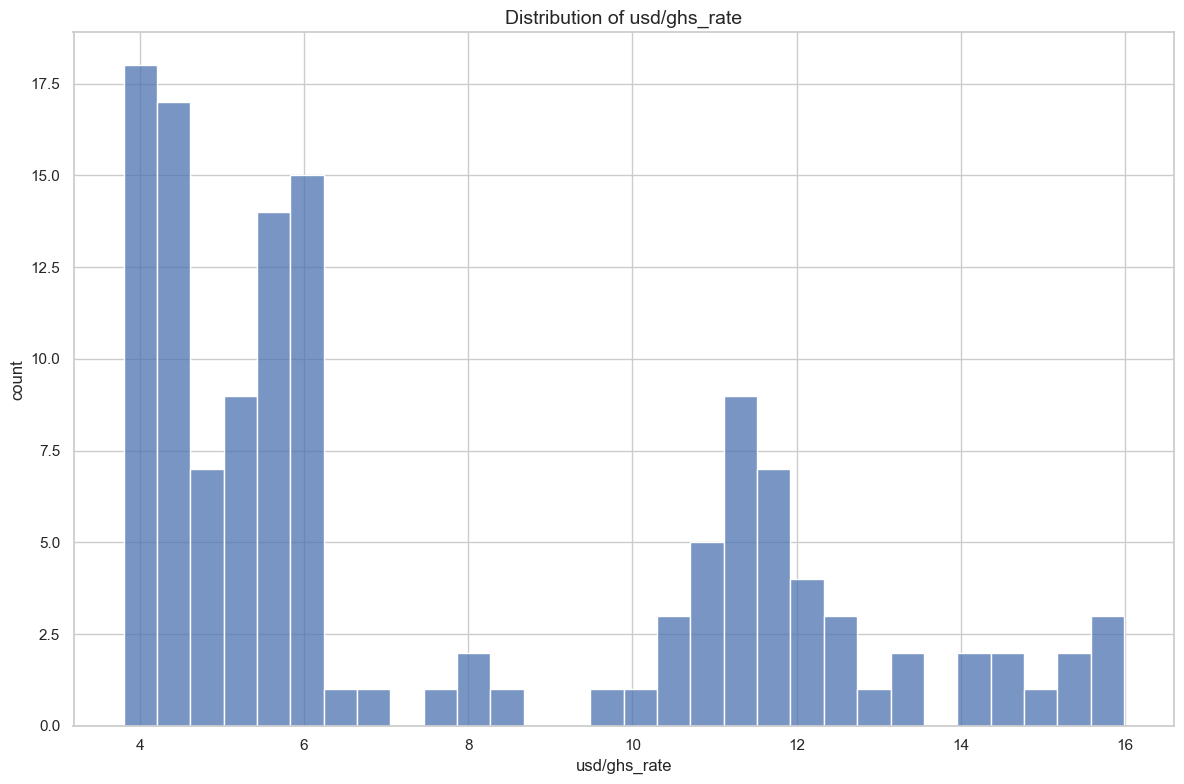

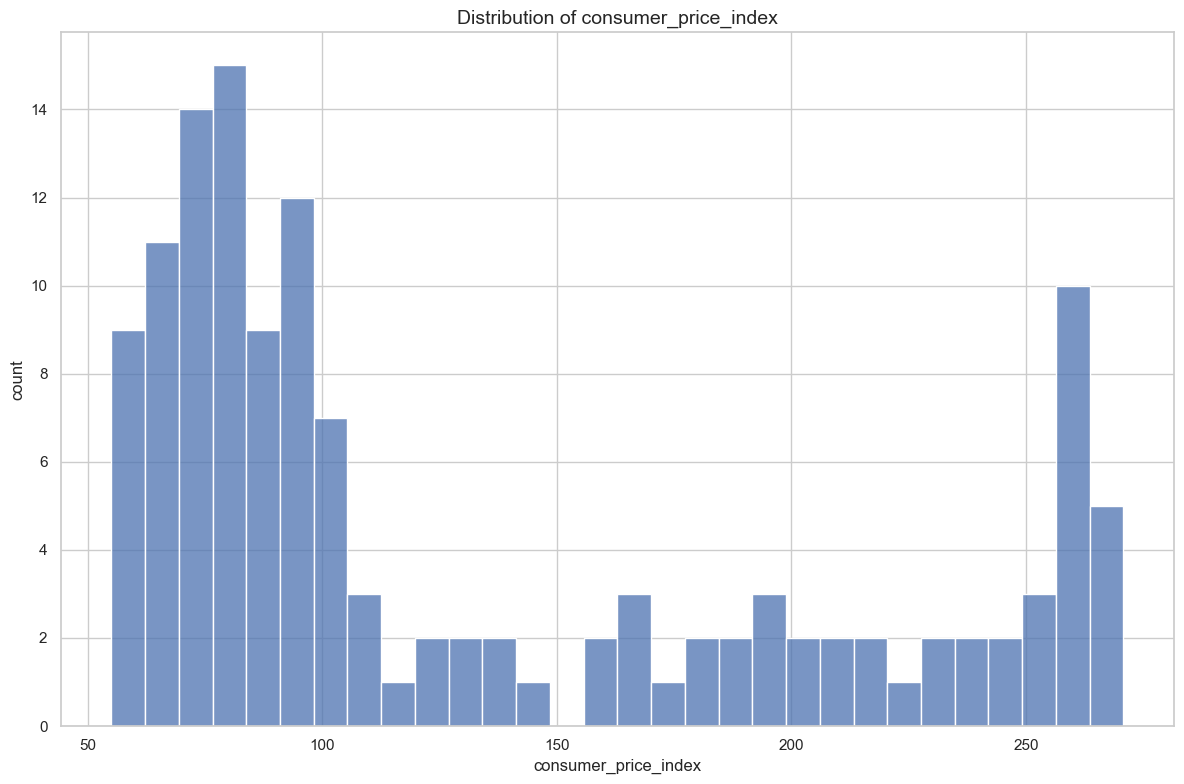

In [21]:
for col in numeric_cols:
    plt.figure(figsize = (12, 8))
    sns.histplot(df[col],  bins = 30)
    plt.title(f"Distribution of {col}", fontsize = 14)
    plt.xlabel(f"{col}", fontsize = 12)
    plt.ylabel("count", fontsize = 12)

    safe_co = col.replace("/", "_").replace("\\", "_")
    # os.makedirs(save_folder, exist_ok=True)
    plt.savefig(
        os.path.join(save_folder, f"hist_{safe_co}.jpeg"),
        dpi=600,
        bbox_inches="tight"
    )
    plt.tight_layout()
    plt.show()


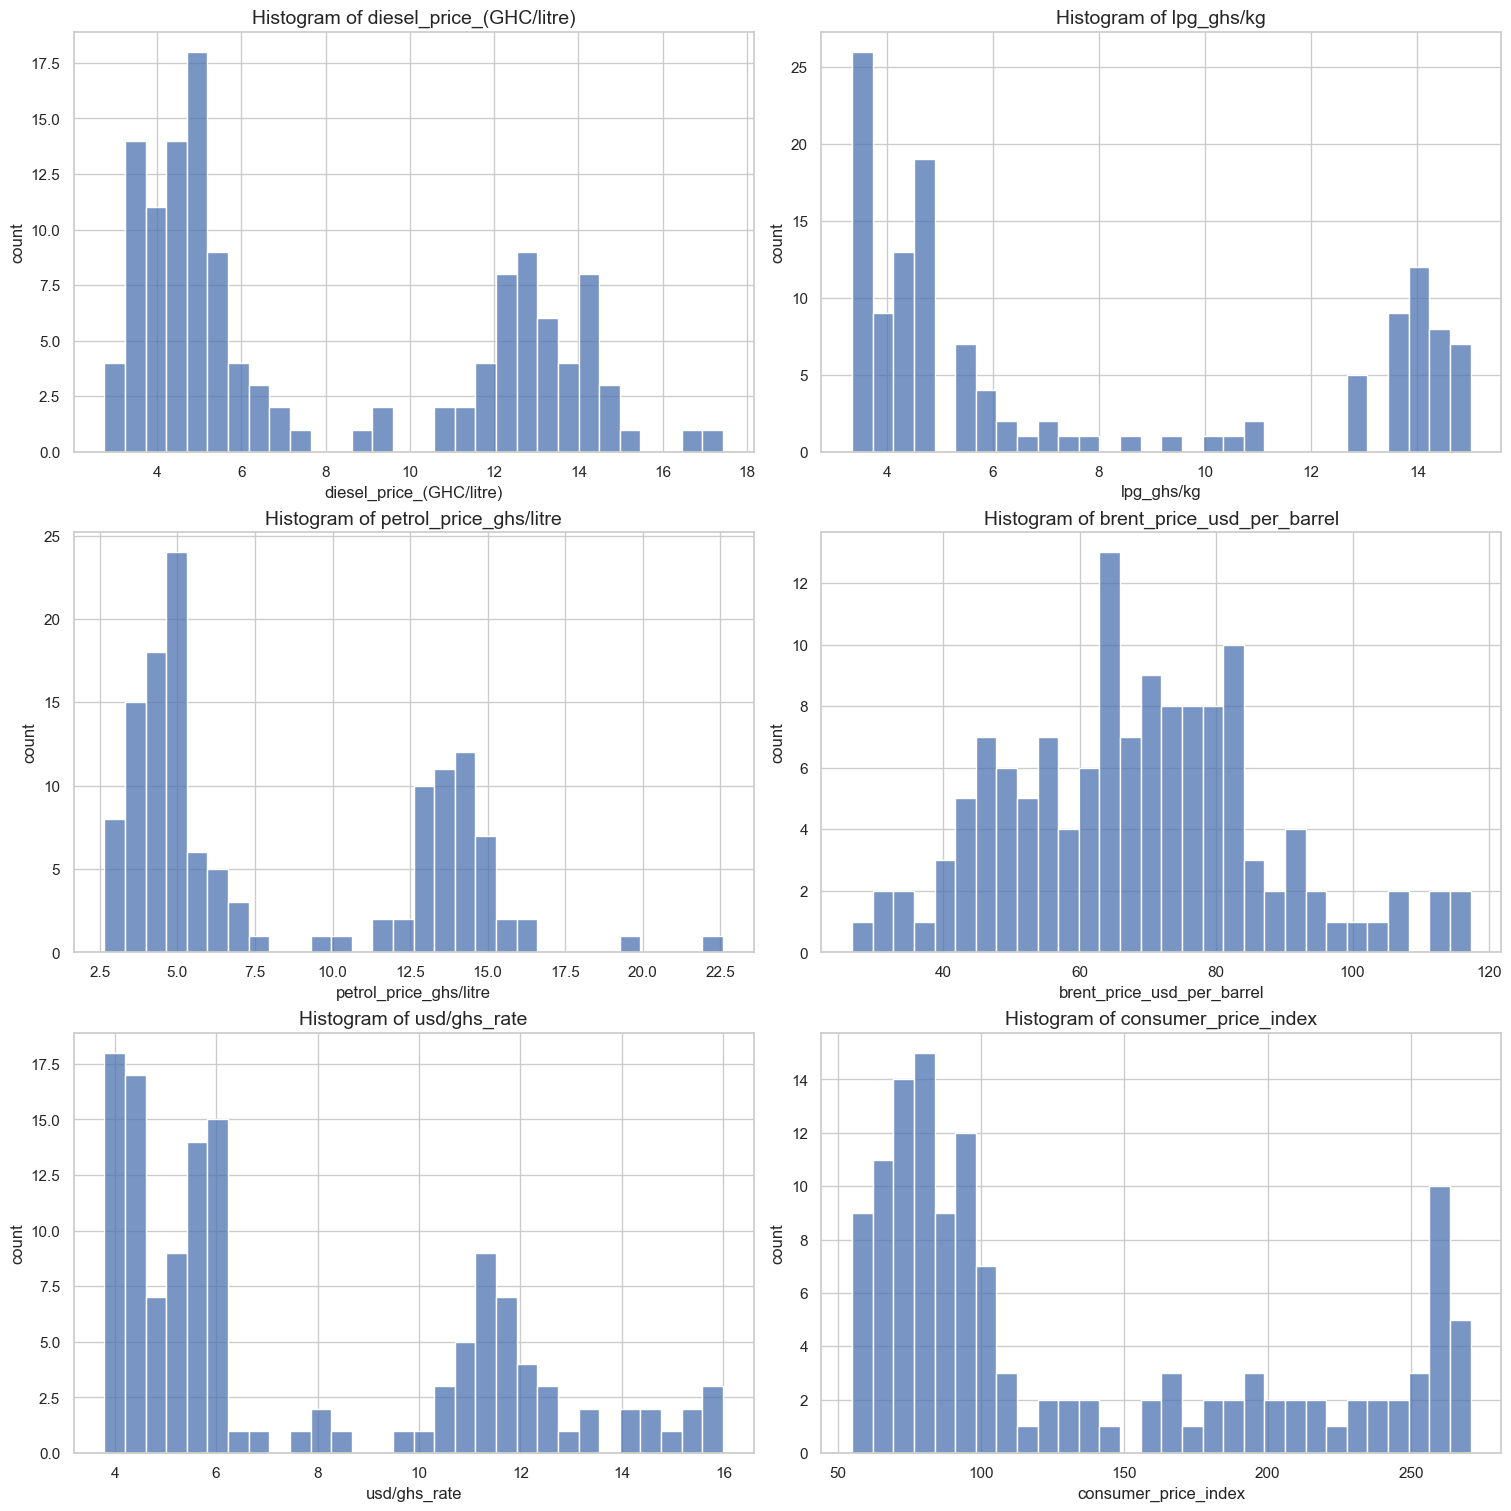

In [81]:
sns.set_theme(style = "whitegrid")
fig, axes = plt.subplots(
    3,
    2,
    figsize = (15, 15),
    constrained_layout = True
)
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.histplot(data = df[col], bins = 30, ax = ax)
    ax.set_title(f"Histogram of {col}", fontsize = 14)
    ax.set_xlabel(f"{col}", fontsize = 12)
    ax.set_ylabel("count", fontsize = 12)

name = "Histogram of the Commoditites Combined"
safe_name = name.replace(" ", "_")
plt.savefig(
    os.path.join(save_folder, f"{safe_name}.jpeg"),
    dpi = 600,
    bbox_inches="tight"
)

plt.show()

## **correlation**

In [82]:
df.corr()

,diesel_price_(GHC/litre),lpg_ghs/kg,petrol_price_ghs/litre,brent_price_usd_per_barrel,usd/ghs_rate,consumer_price_index
diesel_price_(GHC/litre),1.000000,0.960659,0.990871,0.667245,0.955071,0.926133
lpg_ghs/kg,0.960659,1.000000,0.927376,0.551788,0.976718,0.966546
petrol_price_ghs/litre,0.990871,0.927376,1.000000,0.688334,0.921924,0.897708
brent_price_usd_per_barrel,0.667245,0.551788,0.688334,1.000000,0.528603,0.510370
usd/ghs_rate,0.955071,0.976718,0.921924,0.528603,1.000000,0.932346
consumer_price_index,0.926133,0.966546,0.897708,0.510370,0.932346,1.000000


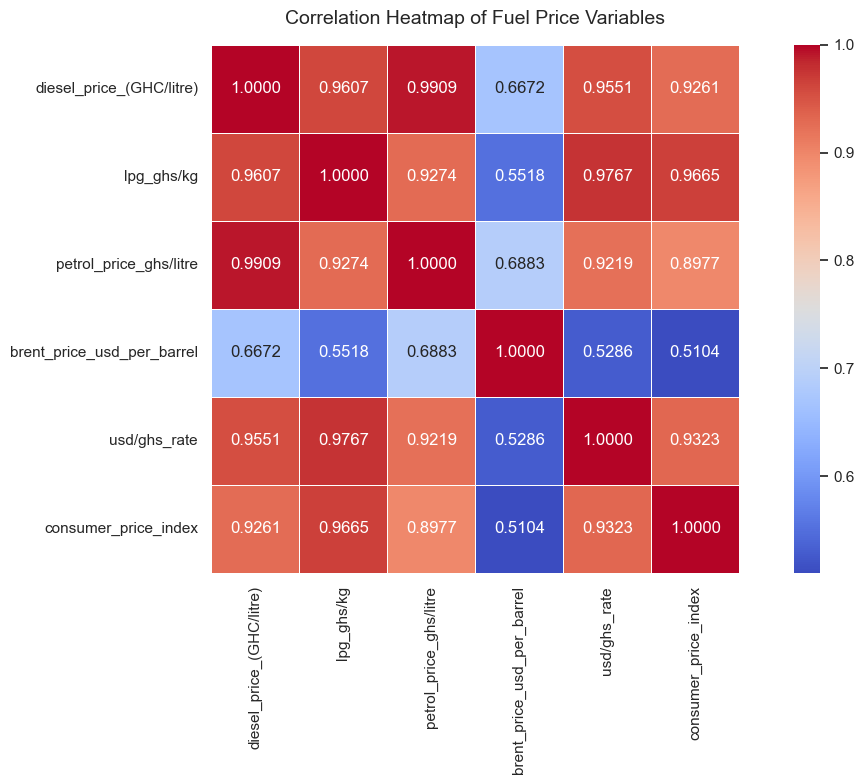

In [96]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt=".4f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True    
)
name = "correlation heatmap of fuel price variables"
safe_name = name.replace(" ", "_")
plt.savefig(
    os.path.join(save_folder, f"{safe_name}jpeg"),
    dpi = 600,
    bbox_inches = "tight"
)

plt.title("Correlation Heatmap of Fuel Price Variables", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## **stationarity testing**

In [32]:
print(df.shape)
print(df.info())
print(df.isna().sum())
print(f"number of duplicates: {df.duplicated().sum()}")

(132, 6)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 132 entries, 2015-07-01 to 2026-06-01
Freq: MS
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   diesel_price_(GHC/litre)    132 non-null    float64
 1   lpg_ghs/kg                  132 non-null    float64
 2   petrol_price_ghs/litre      132 non-null    float64
 3   brent_price_usd_per_barrel  132 non-null    float64
 4   usd/ghs_rate                132 non-null    float64
 5   consumer_price_index        132 non-null    float64
dtypes: float64(6)
memory usage: 7.2 KB
None
diesel_price_(GHC/litre)      0
lpg_ghs/kg                    0
petrol_price_ghs/litre        0
brent_price_usd_per_barrel    0
usd/ghs_rate                  0
consumer_price_index          0
dtype: int64
number of duplicates: 0


In [33]:
df.head()

,diesel_price_(GHC/litre),lpg_ghs/kg,petrol_price_ghs/litre,brent_price_usd_per_barrel,usd/ghs_rate,consumer_price_index
date,,,,,,
2015-07-01,3.70,3.35,3.41,56.8,3.87,55.5
2015-08-01,3.46,3.35,2.76,48.2,3.92,55.1
2015-09-01,3.02,3.35,2.85,48.6,3.97,55.0
2015-10-01,2.85,3.35,2.77,48.1,3.99,56.5
2015-11-01,2.78,3.35,2.68,44.4,3.97,57.1


In [9]:
def stationarity_test(df, column):
    """
    Runs ADF, KPSS and Zivot-Andrews test on the a series at level
    ADF H0: unit root ( non-stationary)
    KPSS H0: stationary
    ZA H0: unit root, allowing for one structural break
    """
    results = {"Series": column}

    adf_stat, adf_p, *_ = adfuller(df[column], autolag = "AIC")
    results["ADF_stat"] = round(adf_stat, 4)
    results["ADF_pvalue"] = round(adf_p, 4)
    results["ADF_conclusion"] = "Stationary" if adf_p < 0.05 else "Non Stationary"

    kpss_stat, kpss_p, *_ = kpss(df[column], regression = "c", nlags = "auto")
    results["KPSS_stat"] = round(kpss_stat, 4)
    results["KPSS_pvalue"] = round(kpss_p, 4)
    results["KPSS_conclusion"] = "Non Stationary" if kpss_p < 0.05 else "Stationary"

    za_stat, za_p, _, _, za_break= zivot_andrews(df[column])
    results["ZA_stat"] = round(za_stat, 4)
    results["ZA_pvalue"] = round(za_p, 4)
    results["ZA_break_date"] = df.index[za_break].strftime("%Y-%m")
    results["ZA_conclusion"] = "Stationary (with break)" if za_p < 0.05 else "Non Stationary"

    return results


def stationarity_test_diff(df, column):
    results = {"Series": column}

    adf_stat, adf_p, *_ = adfuller(df[column], autolag = "AIC")
    results["ADF_stat"] = round(adf_stat, 4)
    results["ADF_pvalue"] = round(adf_p, 4)
    results["ADF_conclusion"] = "Stationary" if adf_p < 0.05 else "Non Stationary"

    kpss_stat, kpss_p, *_ = kpss(df[column], regression = "c", nlags = "auto")
    results["KPSS_stat"] = round(kpss_stat, 4)
    results["KPSS_pvalue"] = round(kpss_p, 4)
    results["KPSS_conclusion"] = "Non Stationary" if kpss_p < 0.05 else "Stationary"

    return results




In [10]:
stationarity_results = [stationarity_test(df, col) for col in num_cols]
stationarity_results_df = pd.DataFrame(stationarity_results)
print("#"*30 + " Stationarity tests at LEVEL " + "#"*30)
print(stationarity_results_df.to_string(index = False))

print("")

df_diff1 = df[num_cols].diff().dropna()
diff1_stationarity_results = [stationarity_test_diff(df_diff1, col) for col in num_cols]
diff1_stationarity_results = pd.DataFrame(diff1_stationarity_results)
print("#"*30 + " Stationarity tests after FIRST DIFFERENCING (d = 1) " + "#"*30)
print(diff1_stationarity_results.to_string(index = False))

print("")
df_diff2 = df[num_cols].diff().diff().dropna()
diff2_stationarity_results = [stationarity_test_diff(df_diff2, col) for col in num_cols]
diff2_stationarity_results = pd.DataFrame(diff2_stationarity_results)
print("#"*30 + " Stationarity tests after FIRST DIFFERENCING (d = 2) for VAR variables " + "#"*30)
print(diff2_stationarity_results.to_string(index = False))

############################## Stationarity tests at LEVEL ##############################
                    Series  ADF_stat  ADF_pvalue ADF_conclusion  KPSS_stat  KPSS_pvalue KPSS_conclusion  ZA_stat  ZA_pvalue ZA_break_date           ZA_conclusion
  diesel_price_(GHC/litre)   -0.7059      0.8452 Non Stationary     1.7488         0.01  Non Stationary  -5.2228     0.0133       2022-01 Stationary (with break)
                lpg_ghs/kg   -1.3448      0.6084 Non Stationary     1.7310         0.01  Non Stationary  -5.7158     0.0018       2022-03 Stationary (with break)
    petrol_price_ghs/litre   -0.7504      0.8333 Non Stationary     1.7097         0.01  Non Stationary  -5.3486     0.0074       2022-02 Stationary (with break)
brent_price_usd_per_barrel   -2.0584      0.2616 Non Stationary     0.9747         0.01  Non Stationary  -3.4362     0.7194       2021-01          Non Stationary
              usd/ghs_rate   -1.1479      0.6956 Non Stationary     1.6635         0.01  Non Station

# **model selection**

In [11]:
fuel_cols = [
    'diesel_price_(GHC/litre)', 
    'lpg_ghs/kg', 
    'petrol_price_ghs/litre'
]
external_cols = [
    'brent_price_usd_per_barrel', 
    'usd/ghs_rate', 
    'consumer_price_index'
]

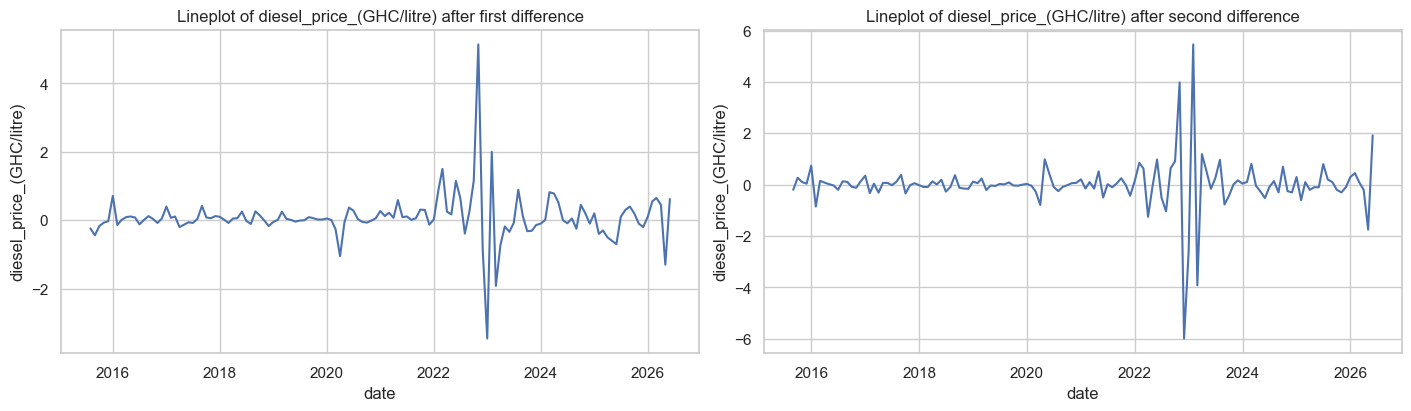

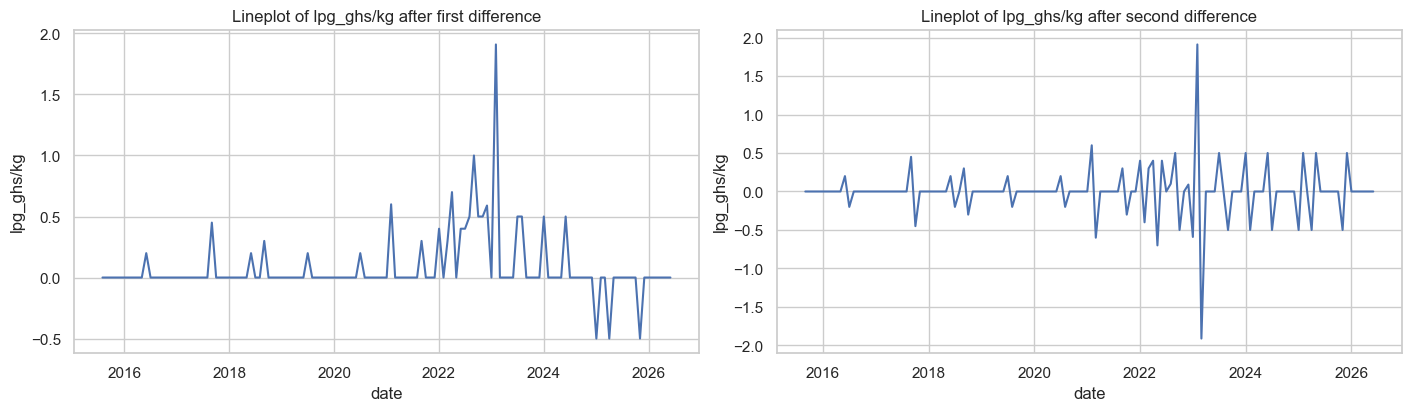

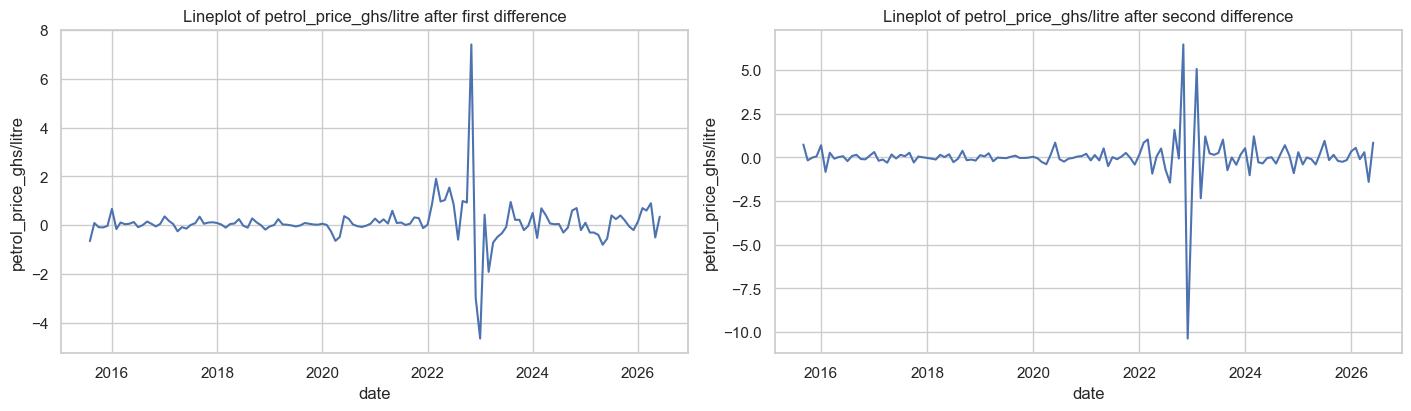

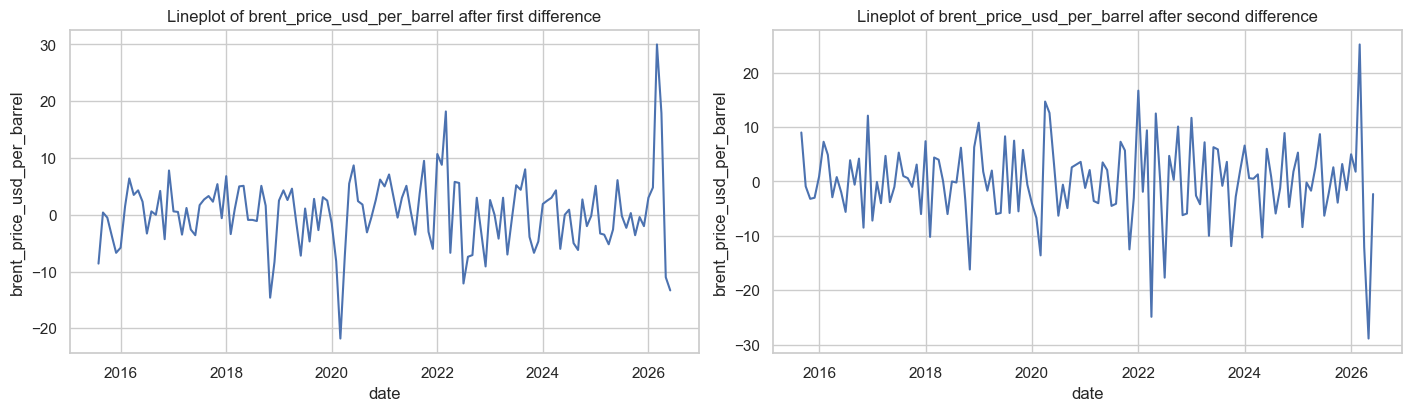

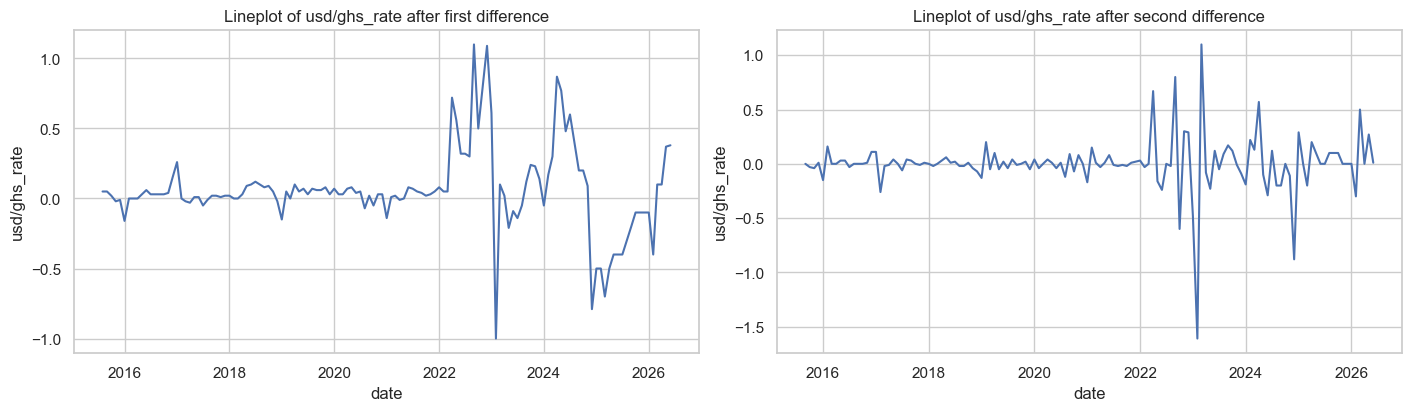

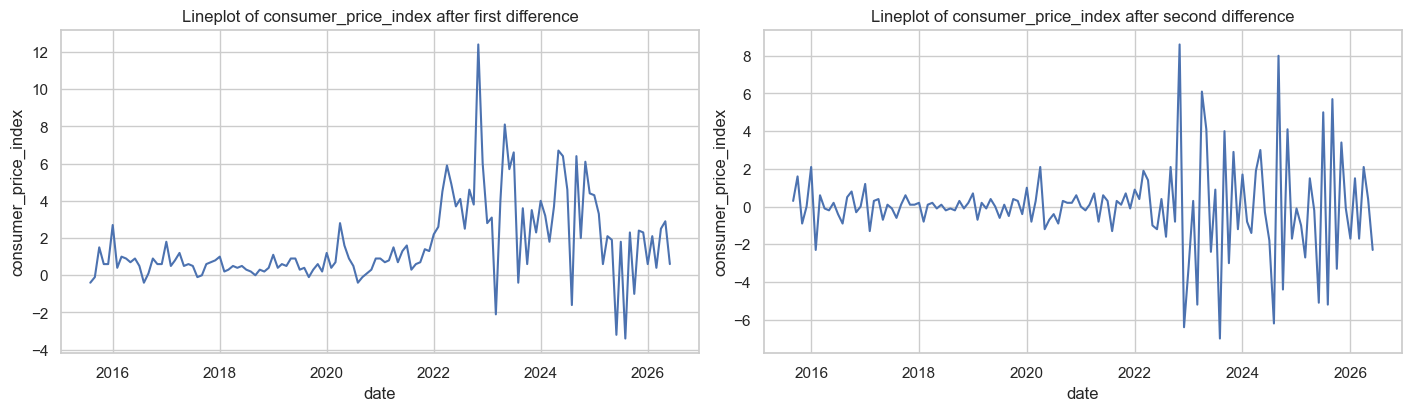

In [12]:
for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize= (14, 4), constrained_layout = True)
    # for column in fuel_cols:
    sns.lineplot(df_diff1[col].dropna(), ax = axes[0])
    sns.lineplot(df_diff2[col].dropna(), ax = axes[1])
    axes[0].set_title(f"Lineplot of {col} after first difference")
    axes[1].set_title(f"Lineplot of {col} after second difference")

In [36]:
df.head()

,diesel_price_(GHC/litre),lpg_ghs/kg,petrol_price_ghs/litre,brent_price_usd_per_barrel,usd/ghs_rate,consumer_price_index
date,,,,,,
2015-07-01,3.70,3.35,3.41,56.8,3.87,55.5
2015-08-01,3.46,3.35,2.76,48.2,3.92,55.1
2015-09-01,3.02,3.35,2.85,48.6,3.97,55.0
2015-10-01,2.85,3.35,2.77,48.1,3.99,56.5
2015-11-01,2.78,3.35,2.68,44.4,3.97,57.1


In [37]:
df.columns

Index(['diesel_price_(GHC/litre)', 'lpg_ghs/kg', 'petrol_price_ghs/litre',
       'brent_price_usd_per_barrel', 'usd/ghs_rate', 'consumer_price_index'],
      dtype='object')

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [14]:
df_diff1.head()

,diesel_price_(GHC/litre),lpg_ghs/kg,petrol_price_ghs/litre,brent_price_usd_per_barrel,usd/ghs_rate,consumer_price_index
date,,,,,,
2015-08-01,-0.24,0.0,-0.65,-8.6,0.05,-0.4
2015-09-01,-0.44,0.0,0.09,0.4,0.05,-0.1
2015-10-01,-0.17,0.0,-0.08,-0.5,0.02,1.5
2015-11-01,-0.07,0.0,-0.09,-3.7,-0.02,0.6
2015-12-01,-0.03,0.0,-0.03,-6.7,-0.01,0.6


In [ ]:
for col in numeric_cols:
    plt.figure(figsize = (12, 8))
    sns.histplot(df[col],  bins = 30)
    plt.title(f"Distribution of {col}", fontsize = 14)
    plt.xlabel(f"{col}", fontsize = 12)
    plt.ylabel("count", fontsize = 12)

    safe_co = col.replace("/", "_").replace("\\", "_")
    # os.makedirs(save_folder, exist_ok=True)
    plt.savefig(
        os.path.join(save_folder, f"hist_{safe_co}.jpeg"),
        dpi=600,
        bbox_inches="tight"
    )
    plt.tight_layout()
    plt.show()


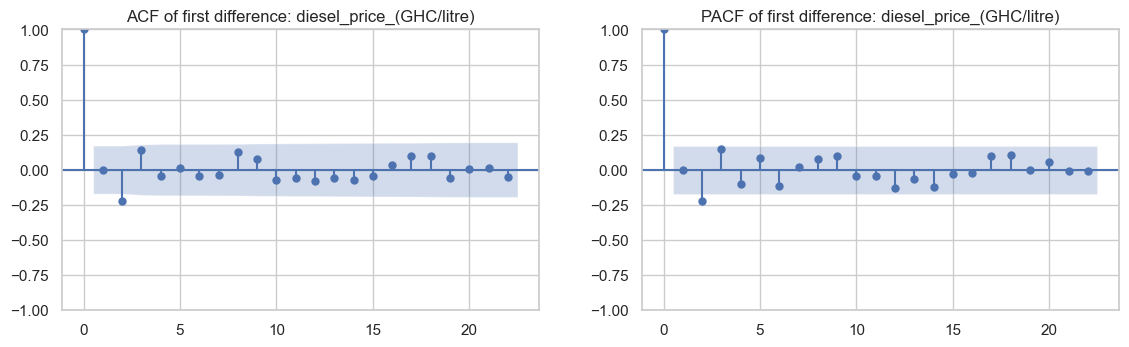

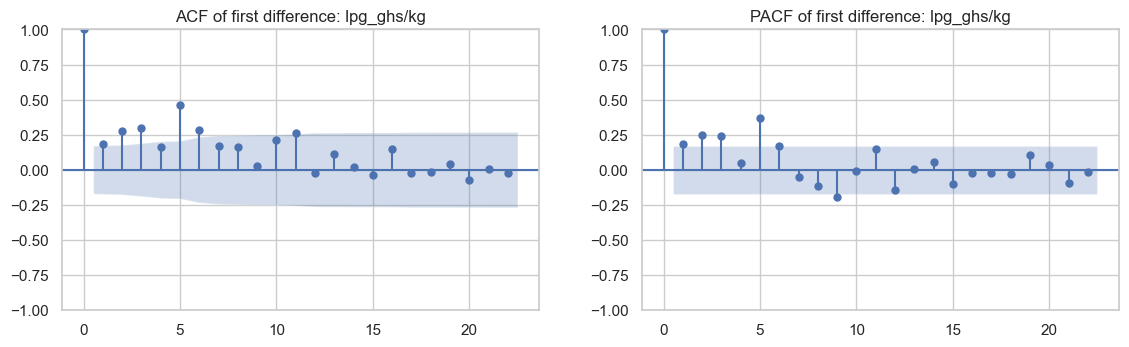

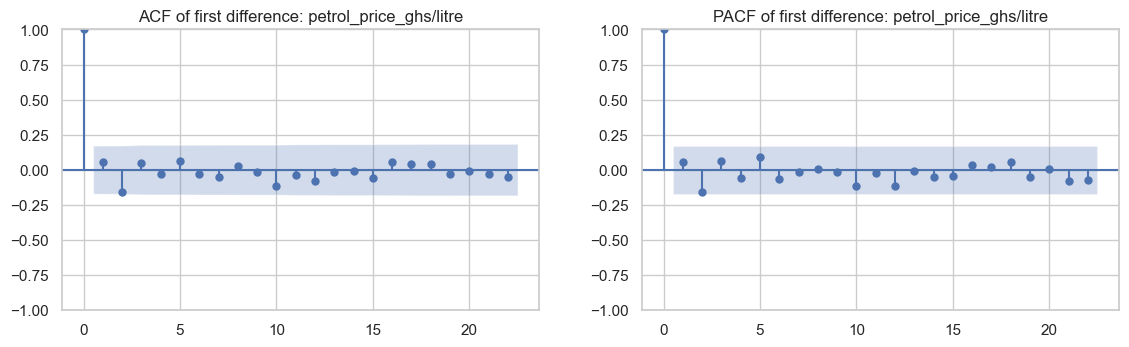

In [ ]:
for col in fuel_cols:
    fig, axes = plt.subplots(
        1, 
        2, 
        figsize = (14, 4), 
        constrained_layout = True
    )
    plot_acf(df_diff1[col], ax = axes[0])
    plot_pacf(df_diff1[col], ax = axes[1])

    axes[0].set_title(f"ACF of first difference: {col}")
    axes[1].set_title(f"PACF of first difference: {col}")
    
    safe_co = col.replace("/", "_").replace("\\", "_")

    os.makedirs(save_folder, exist_ok=True)

    plt.savefig(
        os.path.join(save_folder, f"acf_pacf_1_{safe_co}.jpeg"),
        dpi = 600,
        bbox_inches = "tight"
    )
    plt.tight_layout()
    plt.show()

#### **the abrupt cut off of the pacf is not noticable or could be at 0**
#### **further test would be connducted to select the best model with the lowest AIC and BIC**

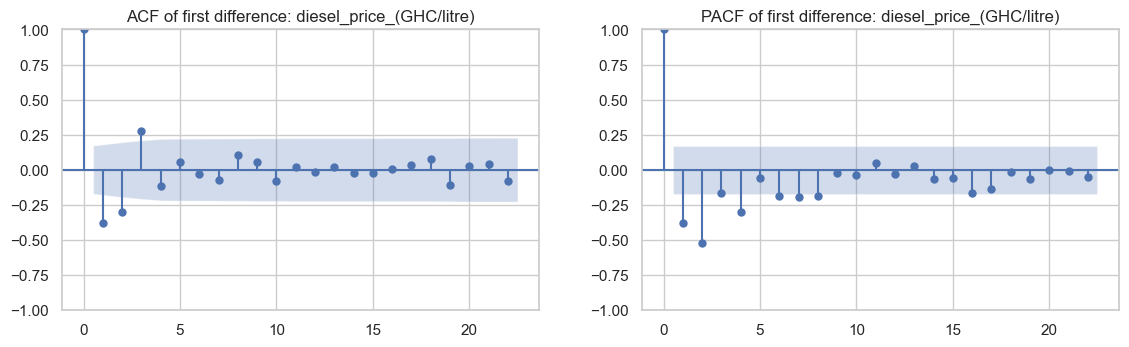

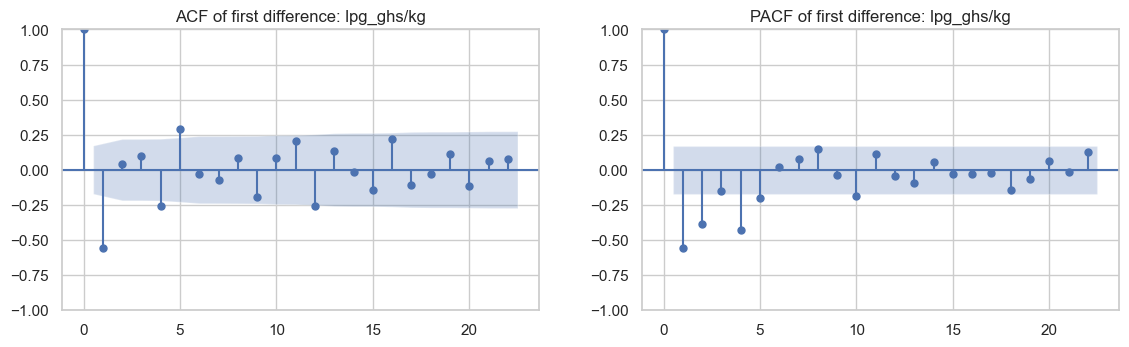

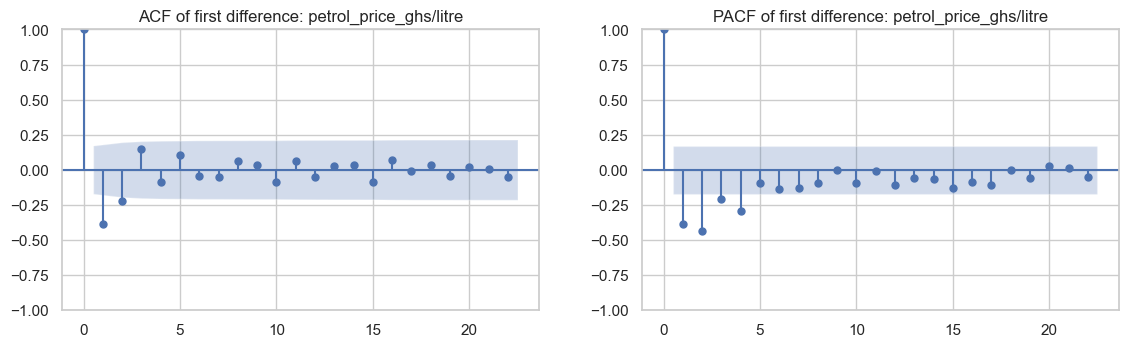

In [52]:
for col in fuel_cols:
    fig, axes = plt.subplots(
        1, 
        2, 
        figsize = (14, 4), 
        constrained_layout = True
    )
    plot_acf(df_diff2[col], ax = axes[0])
    plot_pacf(df_diff2[col], ax = axes[1])

    axes[0].set_title(f"ACF of first difference: {col}")
    axes[1].set_title(f"PACF of first difference: {col}")
    
    safe_c = col.replace("/", "_").replace("\\", "_")

    os.makedirs(save_folder, exist_ok=True)
    
    plt.savefig(
        os.path.join(save_folder, f"acf_pacf_2_{safe_c}.jpeg"),
        dpi = 600,
        bbox_inches = "tight"
    )
    plt.tight_layout()
    plt.show()

#### ***the abrupt cut off of the pacf is not noticable or could be at 0***
#### ***further test would be connducted to select the best model with the lowest AIC and BIC***

# **model p, q selection, model selection based on the best or lowest AIC and BIC**

In [15]:
train = df.loc[:"2025-12-01"]
print("first 3 rows of train data")
print(f"Total training observations: {len(train)}")
print(f"Trainig period is from {df.index.min():%Y-%m} to {train.index.max():%Y-%m}")
print(train.head(3))
print(" ")
print("last 3 rows of train data")
print(train.tail(3))

first 3 rows of train data
Total training observations: 126
Trainig period is from 2015-07 to 2025-12
            diesel_price_(GHC/litre)  lpg_ghs/kg  petrol_price_ghs/litre  \
date                                                                       
2015-07-01                      3.70        3.35                    3.41   
2015-08-01                      3.46        3.35                    2.76   
2015-09-01                      3.02        3.35                    2.85   

            brent_price_usd_per_barrel  usd/ghs_rate  consumer_price_index  
date                                                                        
2015-07-01                        56.8          3.87                  55.5  
2015-08-01                        48.2          3.92                  55.1  
2015-09-01                        48.6          3.97                  55.0  
 
last 3 rows of train data
            diesel_price_(GHC/litre)  lpg_ghs/kg  petrol_price_ghs/litre  \
date                        

In [16]:
test = df.loc["2026-01-01":]
print("first 3 rows of test data")
print(f"Total testing observations: {len(test)}")
print(f"testig period is from {df.index.min():%Y-%m} to {test.index.max():%Y-%m}")
print(test.head(3))
print(" ")
print("last 3 rows of test data")
print(test.tail(3))

first 3 rows of test data
Total testing observations: 6
testig period is from 2015-07 to 2026-06
            diesel_price_(GHC/litre)  lpg_ghs/kg  petrol_price_ghs/litre  \
date                                                                       
2026-01-01                     12.90        13.5                    13.9   
2026-02-01                     13.45        13.5                    14.6   
2026-03-01                     14.10        13.5                    15.2   

            brent_price_usd_per_barrel  usd/ghs_rate  consumer_price_index  
date                                                                        
2026-01-01                        64.6          10.9                 262.3  
2026-02-01                        69.4          10.5                 264.4  
2026-03-01                        99.4          10.6                 264.8  
 
last 3 rows of test data
            diesel_price_(GHC/litre)  lpg_ghs/kg  petrol_price_ghs/litre  \
date                              

## **fitting ARIMA model to determine the order using AIC and BIC**

In [17]:
from statsmodels.tsa.arima.model import ARIMA

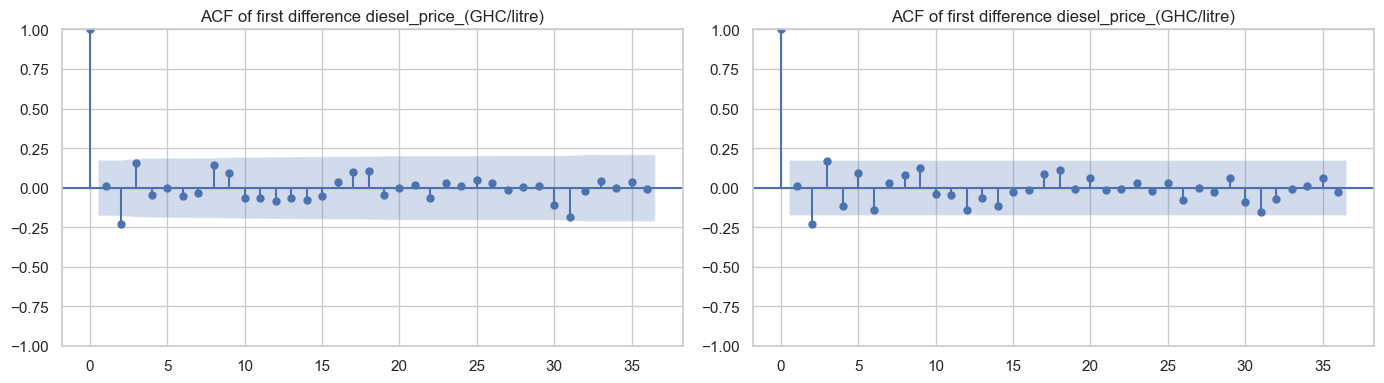

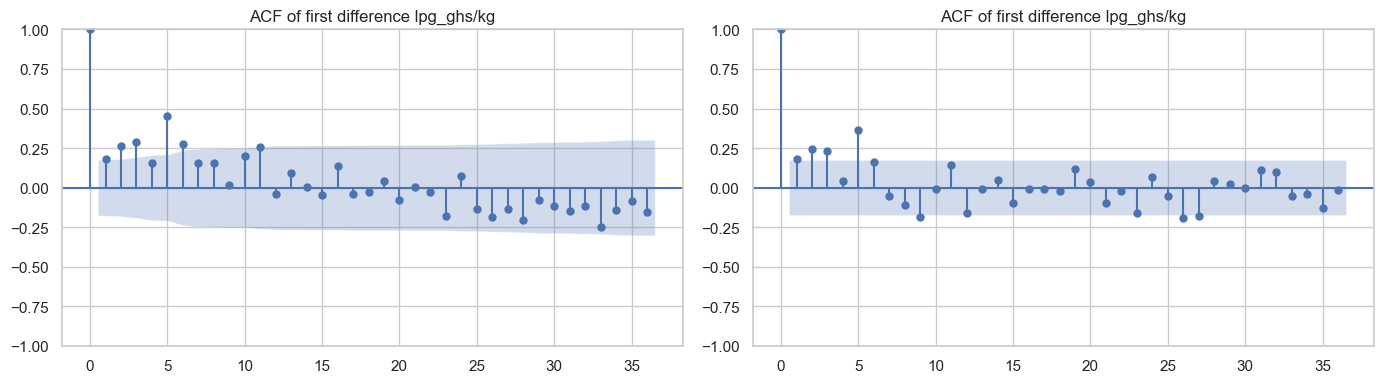

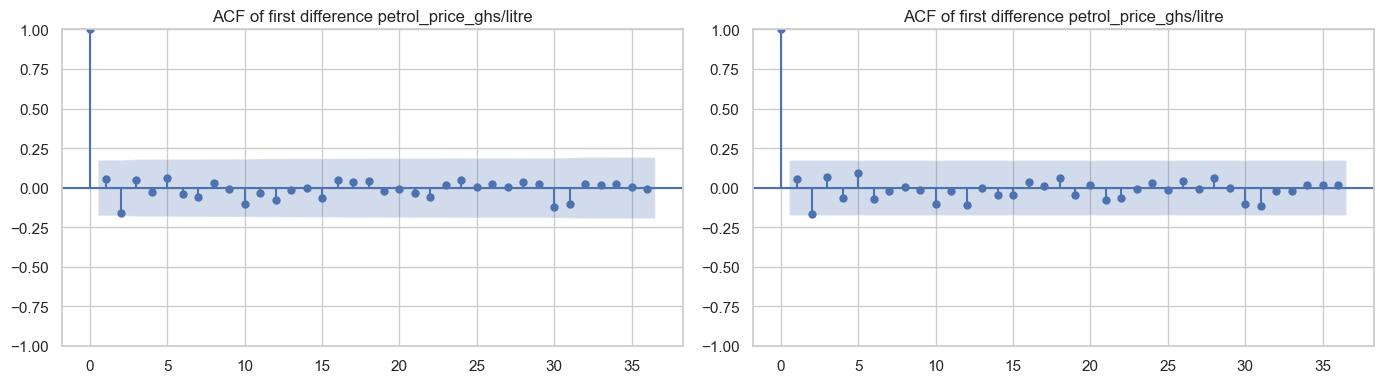

Selected (p,1,q) order per series (lowest AIC):
  diesel_price_(GHC/litre): (0, 1, 3)
  lpg_ghs/kg: (2, 1, 2)
  petrol_price_ghs/litre: (0, 1, 3)

Top 5 candidates per series:


,series,order,AIC,BIC
3,diesel_price_(GHC/litre),"(0, 1, 3)",256.124830,267.307992
7,diesel_price_(GHC/litre),"(1, 1, 3)",257.870829,271.849781
6,diesel_price_(GHC/litre),"(1, 1, 2)",257.999565,269.215650
9,diesel_price_(GHC/litre),"(2, 1, 1)",259.448751,270.697489
10,diesel_price_(GHC/litre),"(2, 1, 2)",259.557835,273.577940
26,lpg_ghs/kg,"(2, 1, 2)",4.929035,18.949140
23,lpg_ghs/kg,"(1, 1, 3)",5.881770,19.860723
22,lpg_ghs/kg,"(1, 1, 2)",6.243843,17.459927
25,lpg_ghs/kg,"(2, 1, 1)",6.680820,17.929558
21,lpg_ghs/kg,"(1, 1, 1)",8.119397,16.555950


In [20]:
candidate_orders = [(p, 1, q) for p in range(4) for q in range(4)]
selected_order = {}
order_rows = []

for col in fuel_cols:
    differenced = train[col].diff().dropna()
    fig, axes = plt.subplots(1, 2, figsize = (14, 4), constrained_layout = True)
    plot_acf(differenced, lags = min(36, len(differenced) // 2 - 1), ax = axes[0])
    plot_pacf(differenced, lags = min(36, len(differenced) // 2 - 1), ax = axes[1], method = "ywm")

    axes[0].set_title(f"ACF of first difference {col}")
    axes[1].set_title(f"ACF of first difference {col}")
    plt.tight_layout()
    plt.show()

    best_order, best_aic = None, float("inf")

    for order in candidate_orders:
        try:
            model = ARIMA(
                train[col], 
                order = order,
                enforce_stationarity=False,
                # enforce_invertibility=False
            ).fit()

            order_rows.append({
                "series": col,
                "order": order,
                "AIC": model.aic,
                "BIC": model.bic                
            })
            
            if model.aic < best_aic:
                best_order, best_aic = order, model.aic
        except (ValueError, np.linalg.LinAlgError):
            continue

    selected_order[col] = best_order

order_table = pd.DataFrame(order_rows).sort_values(["series", "AIC"])

print("Selected (p,1,q) order per series (lowest AIC):")
for col, order in selected_order.items():
    print(f"  {col}: {order}")

print("\nTop 5 candidates per series:")
order_table.groupby("series", group_keys=False).head()
      

## **fitting ARIMA model on TEST data**

In [21]:
selected_order

{'diesel_price_(GHC/litre)': (0, 1, 3),
 'lpg_ghs/kg': (2, 1, 2),
 'petrol_price_ghs/litre': (0, 1, 3)}

#### ****fitting ARIMA model on the TEST data with stationarity and invertibility set to false***

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from statsmodels.stats.diagnostic import acorr_ljungbox

In [23]:
fuel_cols = ["diesel_price_(GHC/litre)", "lpg_ghs/kg", "petrol_price_ghs/litre"]
arima_forcast = pd.DataFrame(index = test.index)
arima_metrics = []
arima_diagnostics = []


for column, order in selected_order.items():
    
    fit = ARIMA(
        train[column],
        order=order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit()
    forcast = fit.forecast(steps = 6)
    arima_forcast[column] = forcast
    
    errors = test[column].to_numpy() - forcast.to_numpy()

    arima_metrics.append(
        {
            "Model" : "ARIMA",
            "Series" : column,
            "Order" : str(order),
            "MAE" : mean_absolute_error(forcast, test[column]),
            "RMSE" : np.sqrt(mean_squared_error(forcast, test[column])),
            "MAPE" : f"{mean_absolute_percentage_error(test[column], forcast):.4%}",
            "MAP": np.mean(np.abs(errors / test[column].to_numpy())) * 100
        }
    )
pd.DataFrame(arima_metrics)
# print(arima_forcast)

            


,Model,Series,Order,MAE,RMSE,MAPE,MAP
0,ARIMA,diesel_price_(GHC/litre),"(0, 1, 3)",0.865232,1.024299,6.1716%,6.171643
1,ARIMA,lpg_ghs/kg,"(2, 1, 2)",0.350799,0.379660,2.5985%,2.598511
2,ARIMA,petrol_price_ghs/litre,"(0, 1, 3)",1.463821,1.653374,9.3759%,9.375928


#### ****fitting ARIMA model on the TEST data with stationarity set to True and invertibility set to false***

In [24]:
fuel_cols = ["diesel_price_(GHC/litre)", "lpg_ghs/kg", "petrol_price_ghs/litre"]
arima_forcast = pd.DataFrame(index = test.index)
arima_metrics = []
arima_diagnostics = []


for column, order in selected_order.items():
    
    fit = ARIMA(
        train[column],
        order=order,
        enforce_stationarity=True,
        enforce_invertibility=False,
    ).fit()
    forcast = fit.forecast(steps = 6)
    arima_forcast[column] = forcast
    
    errors = test[column].to_numpy() - forcast.to_numpy()

    arima_metrics.append(
        {
            "Model" : "ARIMA",
            "Series" : column,
            "Order" : str(order),
            "MAE" : mean_absolute_error(forcast, test[column]),
            "RMSE" : np.sqrt(mean_squared_error(forcast, test[column])),
            "MAPE" : f"{mean_absolute_percentage_error(test[column], forcast):.4%}",
            "MAP": np.mean(np.abs(errors / test[column].to_numpy())) * 100
        }
    )
pd.DataFrame(arima_metrics)
# print(arima_forcast)

            


,Model,Series,Order,MAE,RMSE,MAPE,MAP
0,ARIMA,diesel_price_(GHC/litre),"(0, 1, 3)",0.866184,1.025057,6.1786%,6.178618
1,ARIMA,lpg_ghs/kg,"(2, 1, 2)",0.337578,0.367048,2.5006%,2.500576
2,ARIMA,petrol_price_ghs/litre,"(0, 1, 3)",1.463624,1.653210,9.3746%,9.374618


#### ****fitting ARIMA model on the TEST data with stationarity set to False and invertibility set to True***

In [25]:
fuel_cols = ["diesel_price_(GHC/litre)", "lpg_ghs/kg", "petrol_price_ghs/litre"]
arima_forcast = pd.DataFrame(index = test.index)
arima_metrics = []
arima_diagnostics = []


for column, order in selected_order.items():
    
    fit = ARIMA(
        train[column],
        order=order,
        enforce_stationarity=False,
        enforce_invertibility=True,
    ).fit()
    forcast = fit.forecast(steps = 6)
    arima_forcast[column] = forcast
    
    errors = test[column].to_numpy() - forcast.to_numpy()

    arima_metrics.append(
        {
            "Model" : "ARIMA",
            "Series" : column,
            "Order" : str(order),
            "MAE" : mean_absolute_error(forcast, test[column]),
            "RMSE" : np.sqrt(mean_squared_error(forcast, test[column])),
            "MAPE" : f"{mean_absolute_percentage_error(test[column], forcast):.4%}",
            "MAP": np.mean(np.abs(errors / test[column].to_numpy())) * 100
        }
    )
pd.DataFrame(arima_metrics)
# print(arima_forcast)

            


,Model,Series,Order,MAE,RMSE,MAPE,MAP
0,ARIMA,diesel_price_(GHC/litre),"(0, 1, 3)",0.865237,1.024304,6.1717%,6.171678
1,ARIMA,lpg_ghs/kg,"(2, 1, 2)",0.188837,0.229290,1.3988%,1.398790
2,ARIMA,petrol_price_ghs/litre,"(0, 1, 3)",1.463821,1.653374,9.3759%,9.375929


#### ****fitting ARIMA model on the TEST data with stationarity set to True and invertibility set to True***

#### final model will be selected with stationarity and invertibility set to True


Residual diagnostic summary: diesel_price_(GHC/litre)
     lb_stat  lb_pvalue
10  3.430351    0.96941


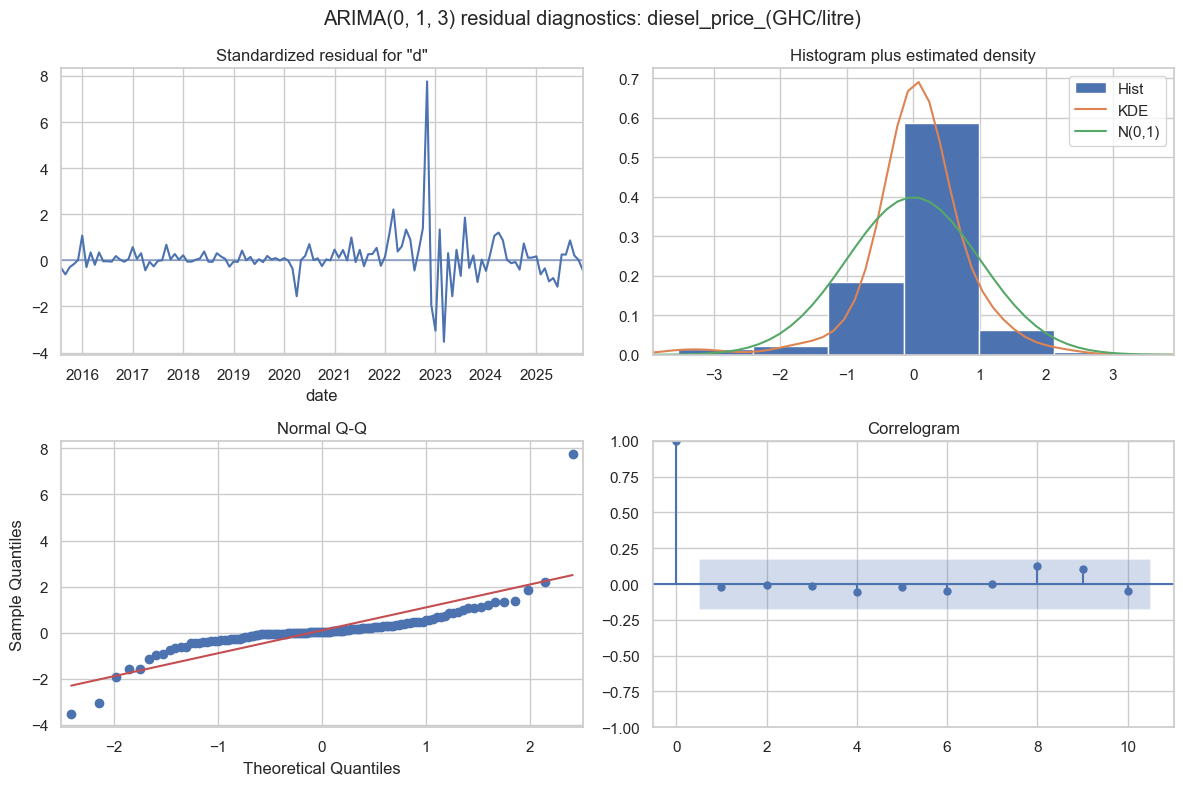


Residual diagnostic summary: lpg_ghs/kg
     lb_stat  lb_pvalue
10  2.893018   0.983831


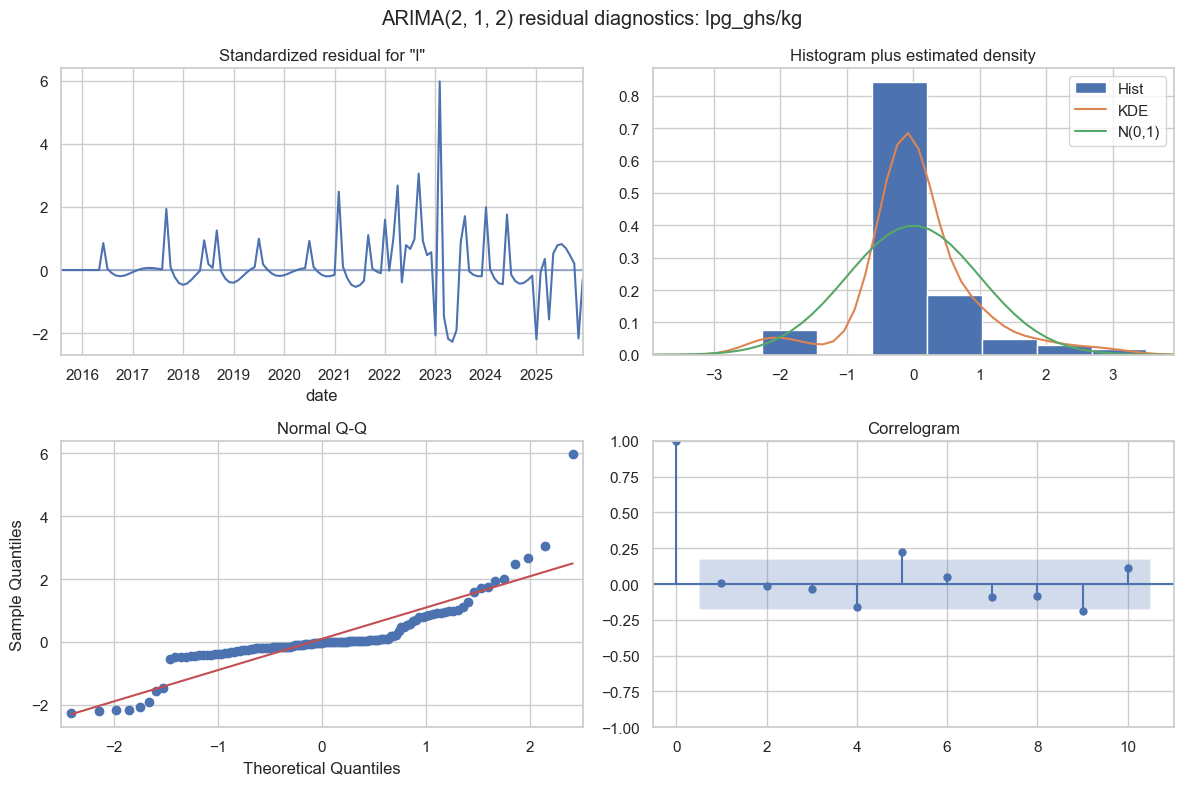


Residual diagnostic summary: petrol_price_ghs/litre
     lb_stat  lb_pvalue
10  2.276856   0.993744


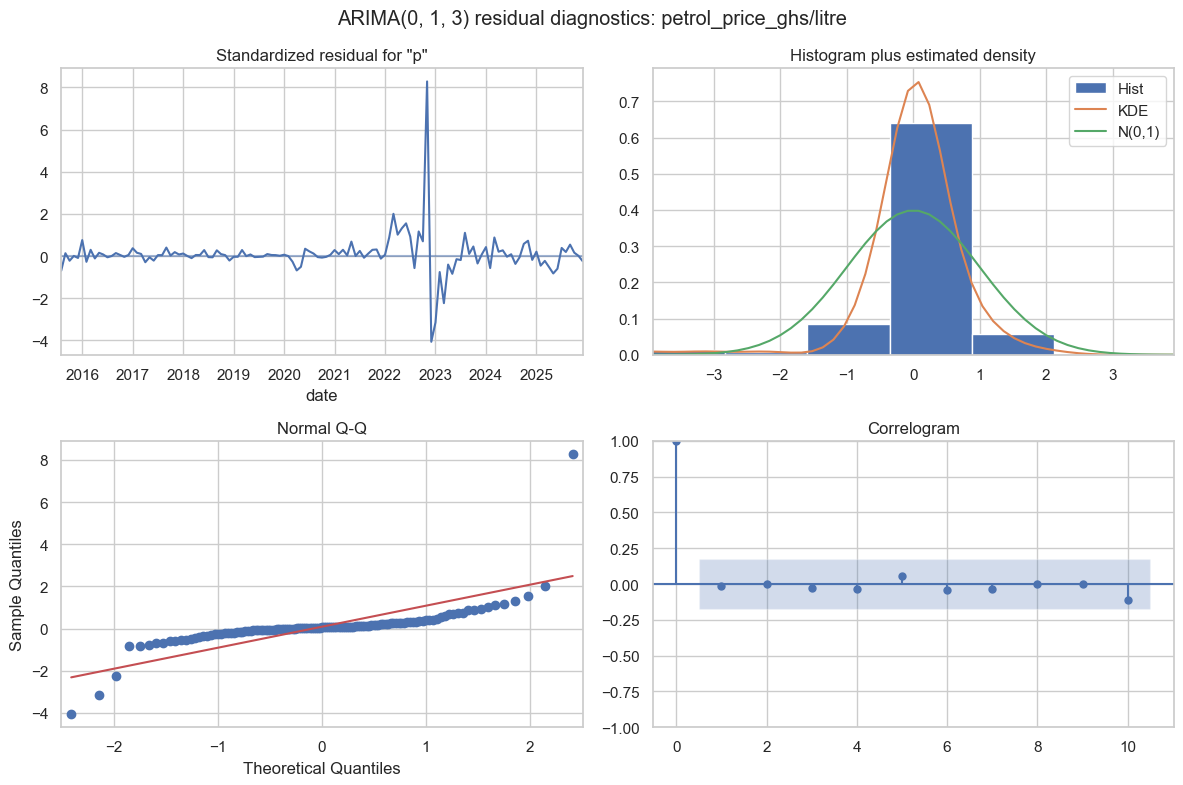

In [26]:
fuel_cols = ["diesel_price_(GHC/litre)", "lpg_ghs/kg", "petrol_price_ghs/litre"]
arima_forcast = pd.DataFrame(index = test.index)
arima_metrics = []
arima_diagnostics = []


for column, order in selected_order.items():
    
    fit = ARIMA(
        train[column],
        order=order,
        enforce_stationarity=True,
        enforce_invertibility=True,
    ).fit()

    forcast = fit.forecast(steps = 6)
    arima_forcast[column] = forcast

    residuals = fit.resid.dropna()
    ljung_box = acorr_ljungbox(residuals, lags = [10], return_df = True)
    arima_diagnostics.append(
        {
            "Series" : column,
            "Order" : str(order),
            "Ljung_Box_pvalue_lag10": ljung_box["lb_pvalue"].iloc[0],

        }
    )
    print(f"\nResidual diagnostic summary: {column}")
    print(ljung_box)
    fit.plot_diagnostics(figsize=(12, 8))
    plt.suptitle(f"ARIMA{order} residual diagnostics: {column}")
    

    safe_co = column.replace("/", "_").replace("\\", "_")
    plt.savefig(
        os.path.join(save_folder, f"diagnostic_arima_{safe_co}.jpeg"),
        dpi=600,
        bbox_inches="tight"
    )
    plt.tight_layout()
    plt.show()
    
    # errors = test[column].to_numpy() - forcast.to_numpy()

    arima_metrics.append(
        {
            "Model" : "ARIMA",
            "Series" : column,
            "Order" : str(order),
            "MAE" : mean_absolute_error(forcast, test[column]),
            "RMSE" : np.sqrt(mean_squared_error(forcast, test[column])),
            "MAPE" : f"{mean_absolute_percentage_error(test[column], forcast):.2%}",
            # "MAP": np.mean(np.abs(errors / test[column].to_numpy())) * 100
        }
    )





Forecast metrics:
   Model                    Series      Order       MAE      RMSE   MAPE
0  ARIMA  diesel_price_(GHC/litre)  (0, 1, 3)  0.866174  1.025049  6.18%
1  ARIMA                lpg_ghs/kg  (2, 1, 2)  0.136154  0.171556  1.01%
2  ARIMA    petrol_price_ghs/litre  (0, 1, 3)  1.463625  1.653211  9.37%

Residual diagnostics:
                     Series      Order  Ljung_Box_pvalue_lag10
0  diesel_price_(GHC/litre)  (0, 1, 3)                0.969410
1                lpg_ghs/kg  (2, 1, 2)                0.983831
2    petrol_price_ghs/litre  (0, 1, 3)                0.993744


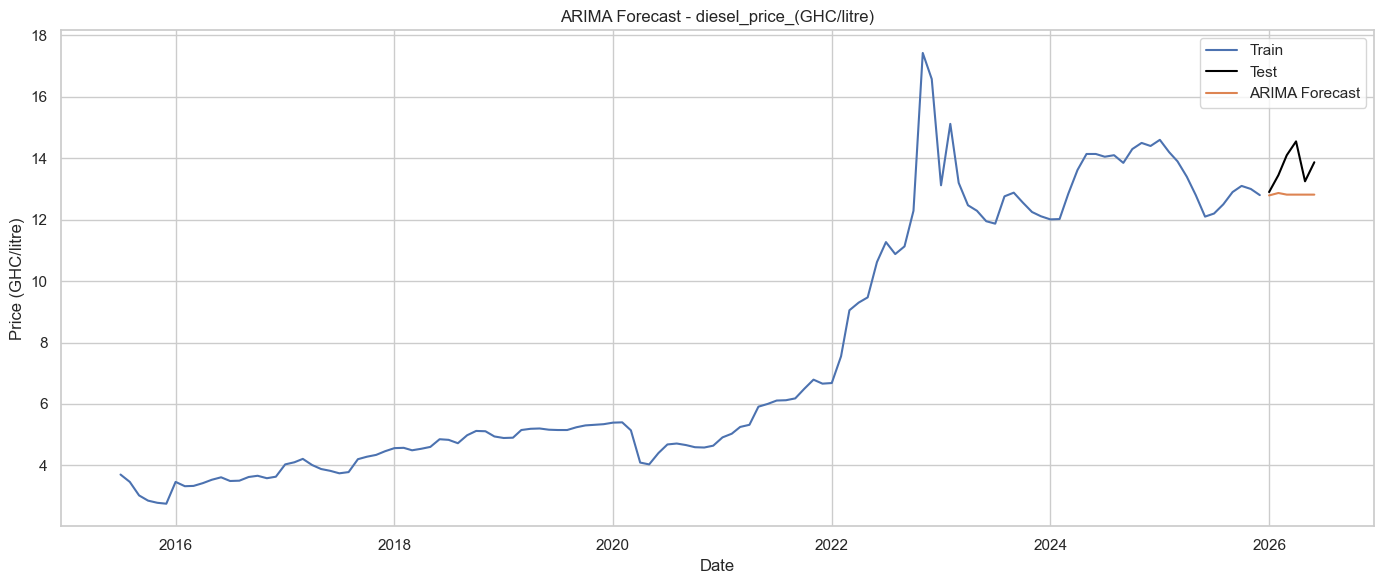

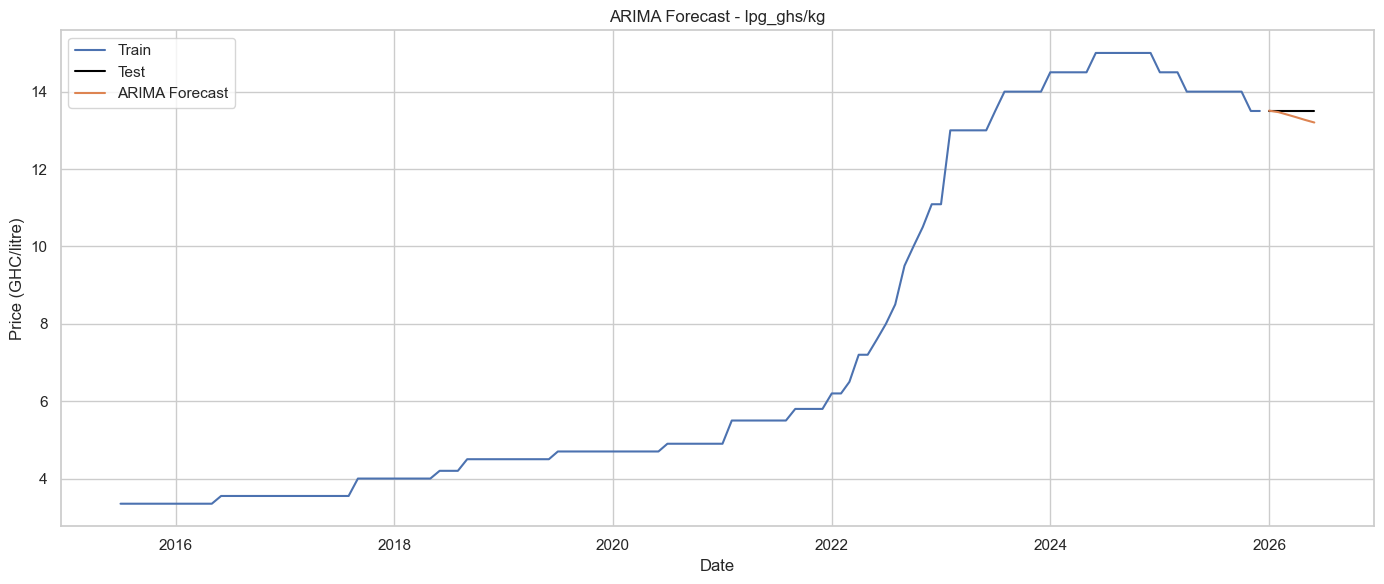

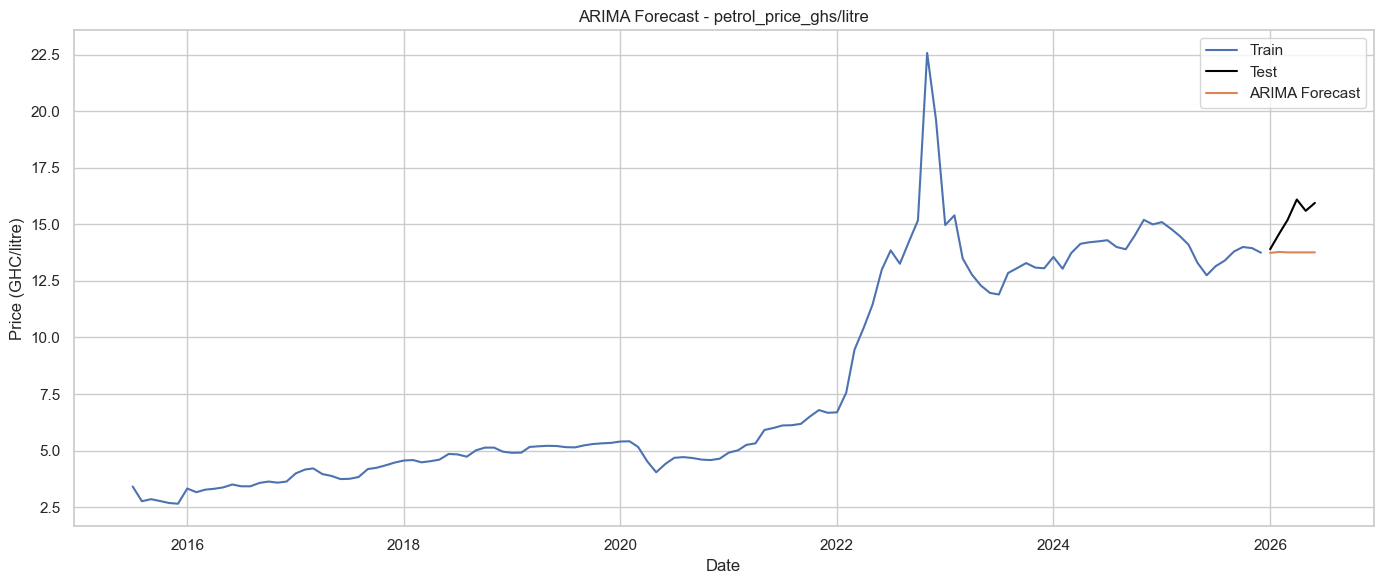

In [235]:
arima_metrics = pd.DataFrame(arima_metrics)
arima_diagnostics = pd.DataFrame(arima_diagnostics)
print("\nForecast metrics:")
print(arima_metrics)
print("\nResidual diagnostics:")
print(arima_diagnostics)

for column in fuel_cols:
    plt.figure(figsize = (14, 6))
    sns.lineplot(x=train.index, y=train[column], label="Train")
    sns.lineplot(x=test.index, y=test[column], color="black", label="Test")
    sns.lineplot(x=arima_forcast.index, y=arima_forcast[column], label="ARIMA Forecast")

    plt.title(f"ARIMA Forecast - {column}")
    plt.xlabel("Date")
    plt.ylabel("Price (GHC/litre)")
    plt.legend()

    safe_col = column.replace("/", "_").replace("\\", "_")
    plt.savefig(
        os.path.join(save_folder, f"ARIMA_FORCAST_{safe_col}.jpeg"),
        dpi=600,
        bbox_inches="tight"
    )
    plt.tight_layout()
    plt.show()

## **fitting ARIMAX model to determine the order using AIC and BIC**

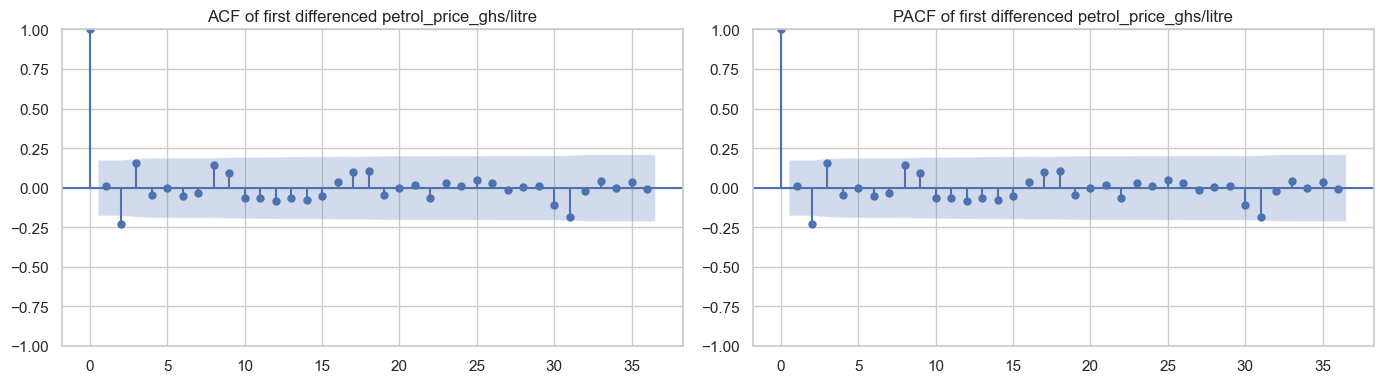

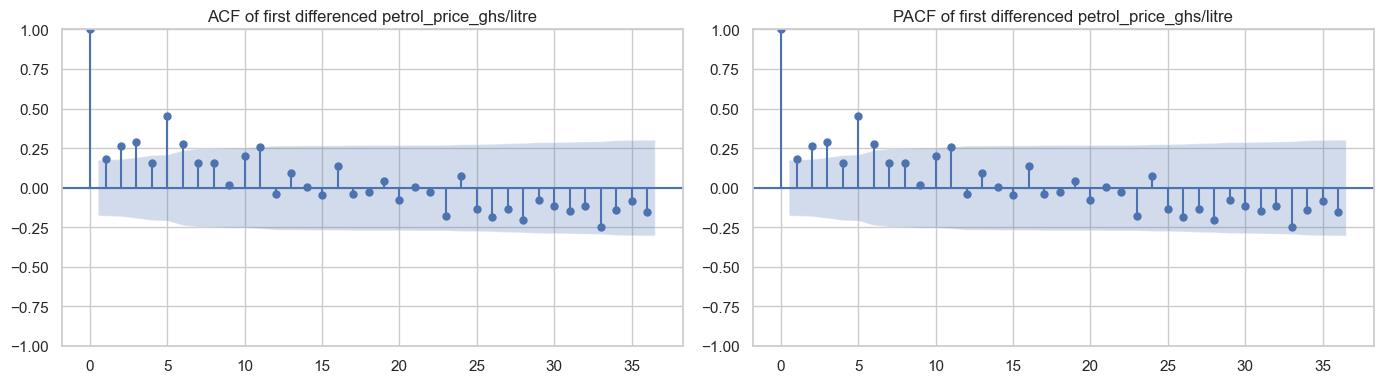

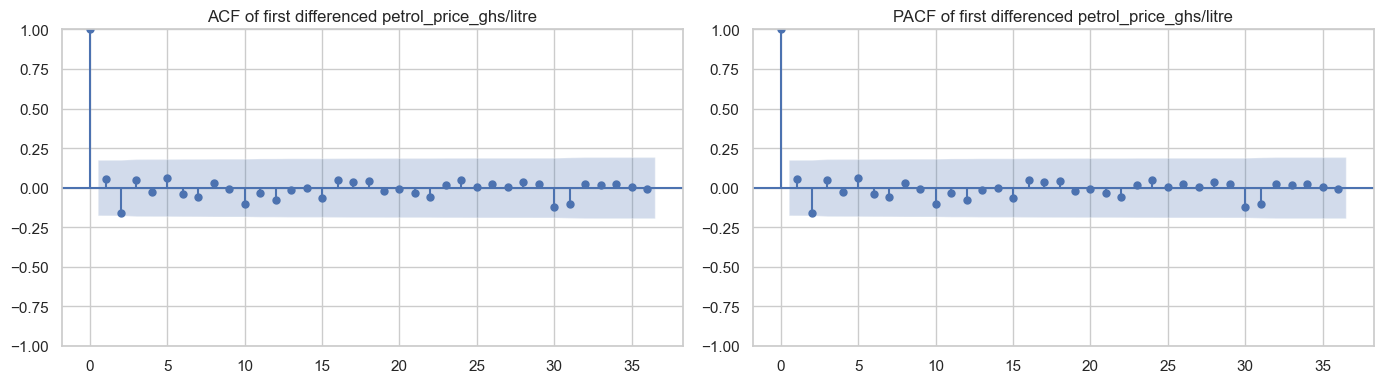

Selected ARIMAX orders from training data:
{'diesel_price_(GHC/litre)': (0, 1, 3), 'lpg_ghs/kg': (1, 1, 3), 'petrol_price_ghs/litre': (0, 1, 3)}
                      Series      Order         AIC         BIC
23                lpg_ghs/kg  (1, 1, 3)   10.799551   33.165875
21                lpg_ghs/kg  (1, 1, 1)   10.955633   27.828740
25                lpg_ghs/kg  (2, 1, 1)   11.062884   30.748175
22                lpg_ghs/kg  (1, 1, 2)   11.293740   30.921887
29                lpg_ghs/kg  (3, 1, 1)   11.413885   33.846054
3   diesel_price_(GHC/litre)  (0, 1, 3)  239.713821  259.284355
7   diesel_price_(GHC/litre)  (1, 1, 3)  241.611064  263.977388
12  diesel_price_(GHC/litre)  (3, 1, 0)  241.768174  261.396322
6   diesel_price_(GHC/litre)  (1, 1, 2)  241.948653  261.576801
10  diesel_price_(GHC/litre)  (2, 1, 2)  242.040363  264.472531
35    petrol_price_ghs/litre  (0, 1, 3)  319.909431  339.479964
39    petrol_price_ghs/litre  (1, 1, 3)  321.684652  344.050976
38    petrol_price_ghs/

In [234]:
arimax_candidate_orders = [(p, 1, q) for p in range(4) for q in range(4)]
selected_arimax_orders = {}
arimax_selected_rows = []

for col in fuel_cols:
    differenced = train[col].diff().dropna()
    fig, axes = plt.subplots(
        1,
        2,
        figsize = (14, 4),
        constrained_layout = True
    )
    plot_acf(
        differenced, 
        lags=min(36, len(differenced) // 2 - 1), 
        ax = axes[0]
    )
    plot_acf(
        differenced, 
        lags=min(36, len(differenced) // 2 - 1), 
        ax = axes[1]
    )
    axes[0].set_title(f"ACF of first differenced {column}")
    axes[1].set_title(f"PACF of first differenced {column}")
    plt.tight_layout()
    plt.show()

    best_aic, best_order = float("Inf"), None
    for order in arimax_candidate_orders:
        try:
            arimax_fit = ARIMA(
                train[col], 
                exog = train[external_cols],
                order = order,
                enforce_stationarity = False
                ).fit()
            
            arimax_selected_rows.append(
                {
                    "Series" : col,
                    "Order" : order,
                    "AIC" : arimax_fit.aic,
                    "BIC" : arimax_fit.bic
                }
            )

            if arimax_fit.aic < best_aic:
                best_aic, best_order = arimax_fit.aic, order

        except (ValueError, np.linalg.LinAlgError):
            continue

        selected_arimax_orders[col] = best_order
arimax_selection_table = pd.DataFrame(arimax_selected_rows).sort_values(["AIC", "BIC"])

print("Selected ARIMAX orders from training data:")
print(selected_arimax_orders)
print(arimax_selection_table.groupby("Series").head())


## **fitting ARIMAX model on TEST data**

In [227]:
selected_arimax_orders

{'diesel_price_(GHC/litre)': (0, 1, 3),
 'lpg_ghs/kg': (1, 1, 3),
 'petrol_price_ghs/litre': (0, 1, 3)}

#### ****fitting ARIMA model on the TEST data with stationarity set to True and invertibility set to True***


Residual diagnostic summary: diesel_price_(GHC/litre)
     lb_stat  lb_pvalue
10  2.276856   0.993744


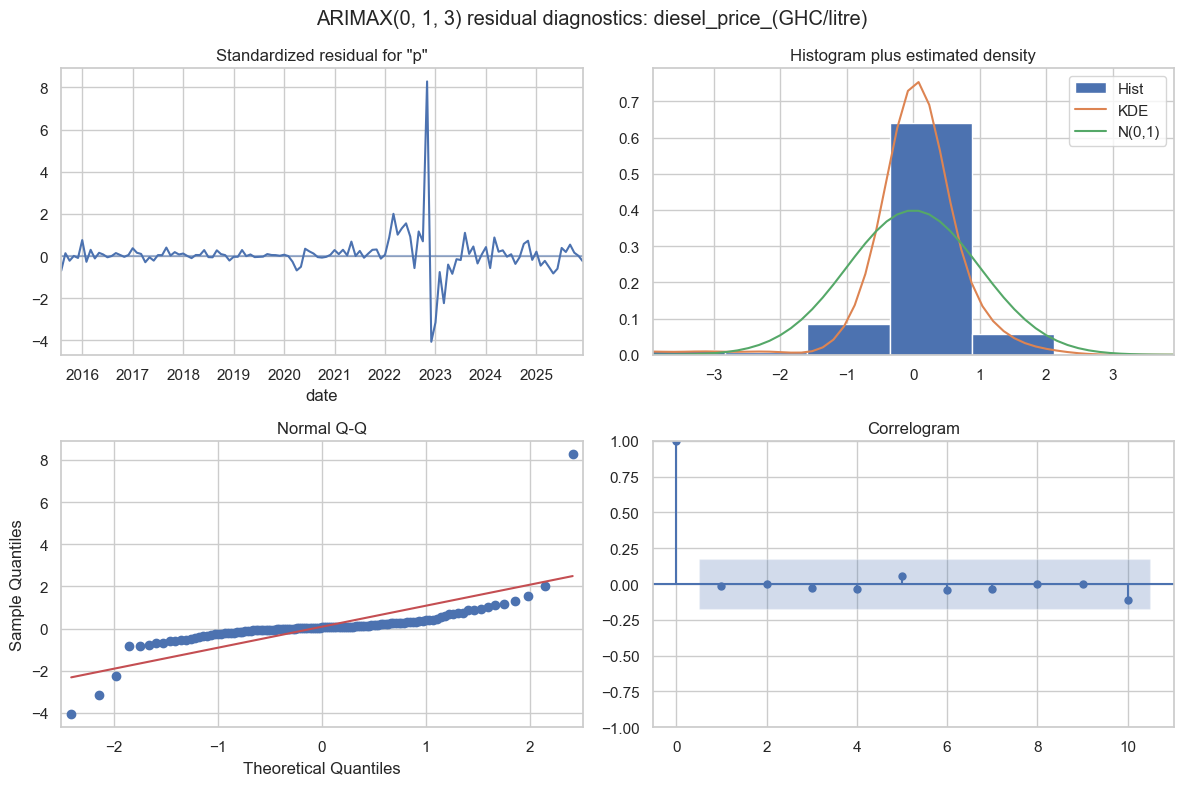


Residual diagnostic summary: lpg_ghs/kg
     lb_stat  lb_pvalue
10  2.276856   0.993744


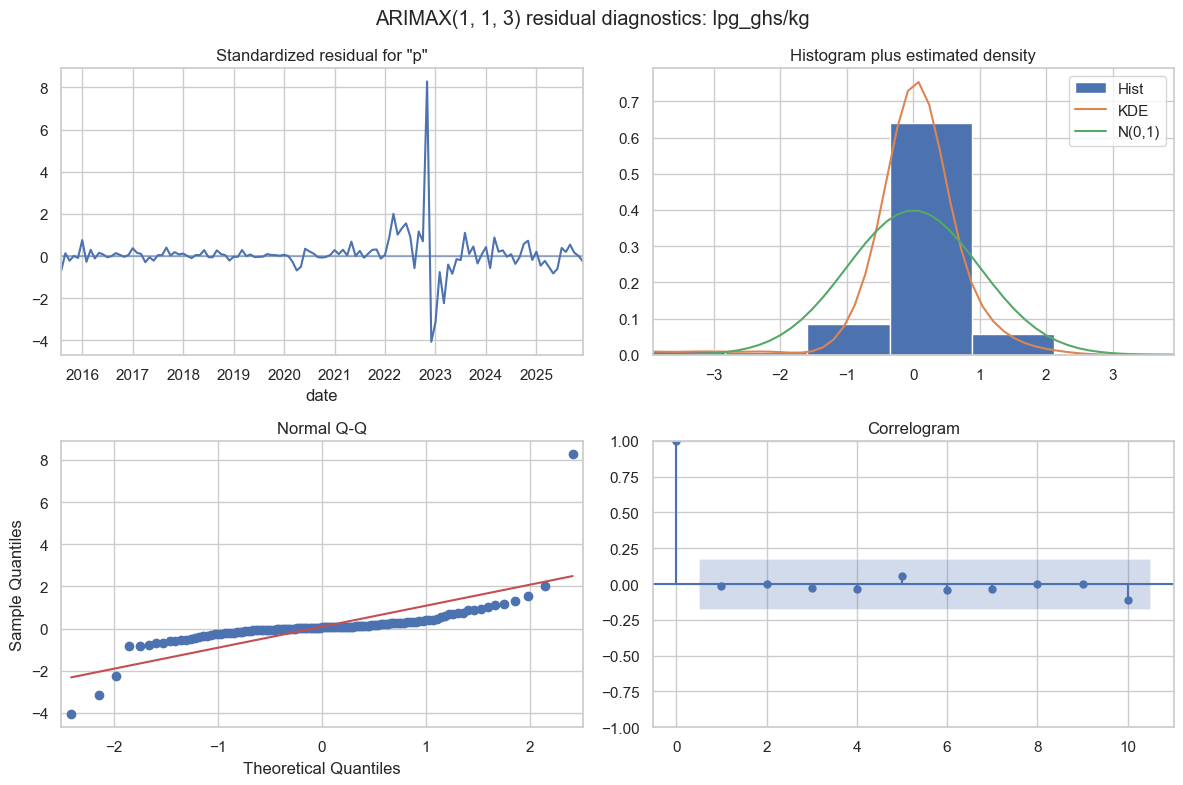


Residual diagnostic summary: petrol_price_ghs/litre
     lb_stat  lb_pvalue
10  2.276856   0.993744


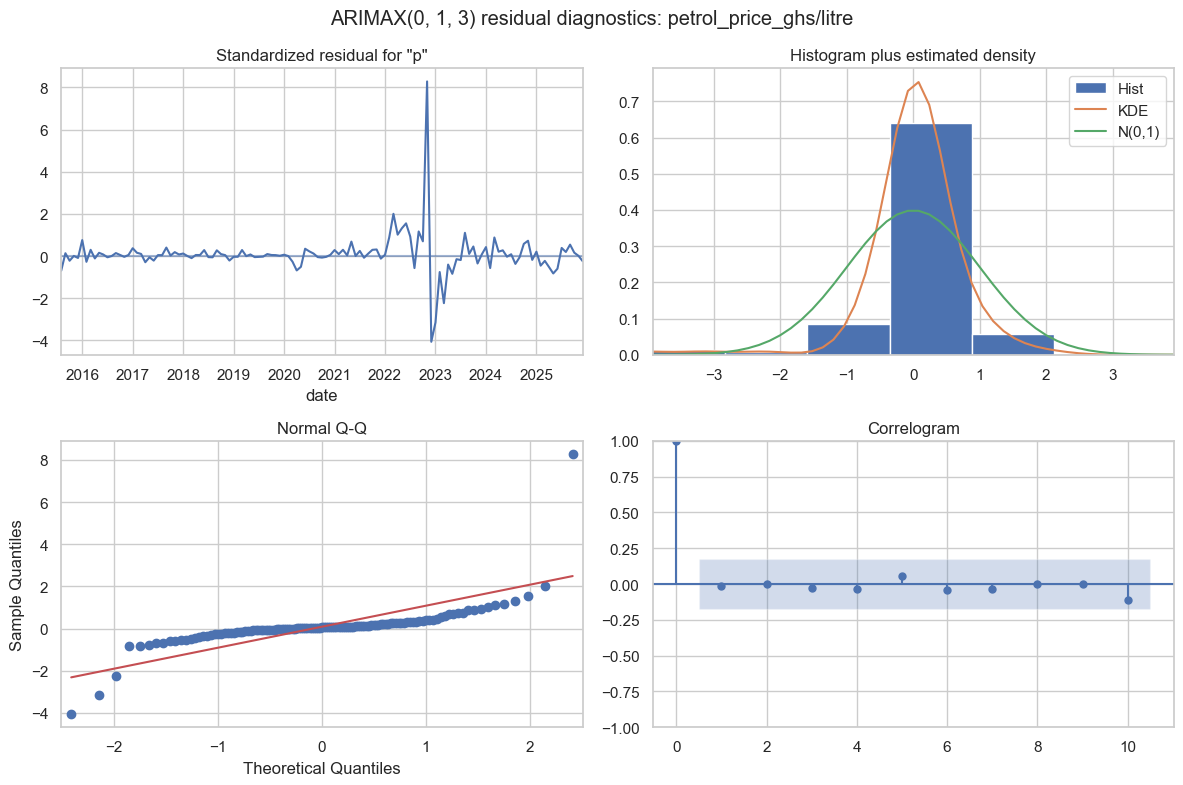

In [229]:
arimax_forecast = pd.DataFrame(index = test.index)
arimax_metrics = []
arimax_diagnostics = []

for col, order in selected_arimax_orders.items():
    arimax_fit = ARIMA(
        train[col],
        order = order,
        exog = train[external_cols],
        enforce_stationarity = True
    ).fit()

    forecast = arimax_fit.forecast(steps = 6, exog = test[external_cols])
    arimax_forecast[col] = forecast

    residuals = fit.resid.dropna()
    ljung_box = acorr_ljungbox(residuals, lags = [10], return_df = True)
    arimax_diagnostics.append(
        {
            "Series" : col,
            "Order" : str(order),
            "Ljung_Box_pvalue_lag10": ljung_box["lb_pvalue"].iloc[0],

        }
    )
    print(f"\nResidual diagnostic summary: {col}")
    print(ljung_box)
    fit.plot_diagnostics(figsize=(12, 8))
    plt.suptitle(f"ARIMAX{order} residual diagnostics: {col}")
    

    safe_co = col.replace("/", "_").replace("\\", "_")
    plt.savefig(
        os.path.join(save_folder, f"diagnostic_arimax_{safe_co}.jpeg"),
        dpi=600,
        bbox_inches="tight"
    )
    plt.tight_layout()
    plt.show()

    arimax_metrics.append(
        {
            
            "Model" : "ARIMAX ",
            "Series" : col,
            "Order" : str(order),
            "MAE" : mean_absolute_error(forecast, test[col]),
            "RMSE" : np.sqrt(mean_squared_error(forecast, test[col])),
            "MAPE" : f"{mean_absolute_percentage_error(test[col], forecast):.2%}",
            # "MAPE": np.mean(np.abs(errors / test[col].to_numpy())) * 100
                    
        }
    )


Forecast metrics:
     Model                    Series      Order       MAE      RMSE   MAPE
0  ARIMAX   diesel_price_(GHC/litre)  (0, 1, 3)  0.434436  0.624113  3.23%
1  ARIMAX                 lpg_ghs/kg  (1, 1, 3)  0.111136  0.128970  0.82%
2  ARIMAX     petrol_price_ghs/litre  (0, 1, 3)  0.262160  0.288744  1.72%

Residual diagnostics:
                     Series      Order  Ljung_Box_pvalue_lag10
0  diesel_price_(GHC/litre)  (0, 1, 3)                0.993744
1                lpg_ghs/kg  (1, 1, 3)                0.993744
2    petrol_price_ghs/litre  (0, 1, 3)                0.993744


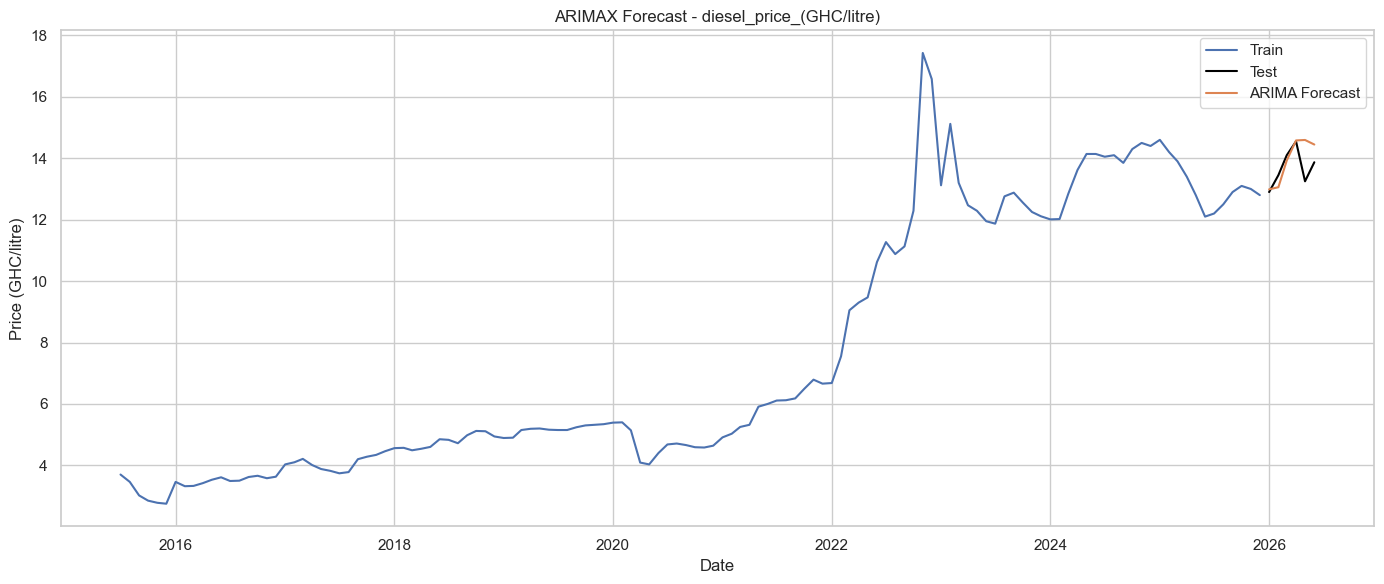

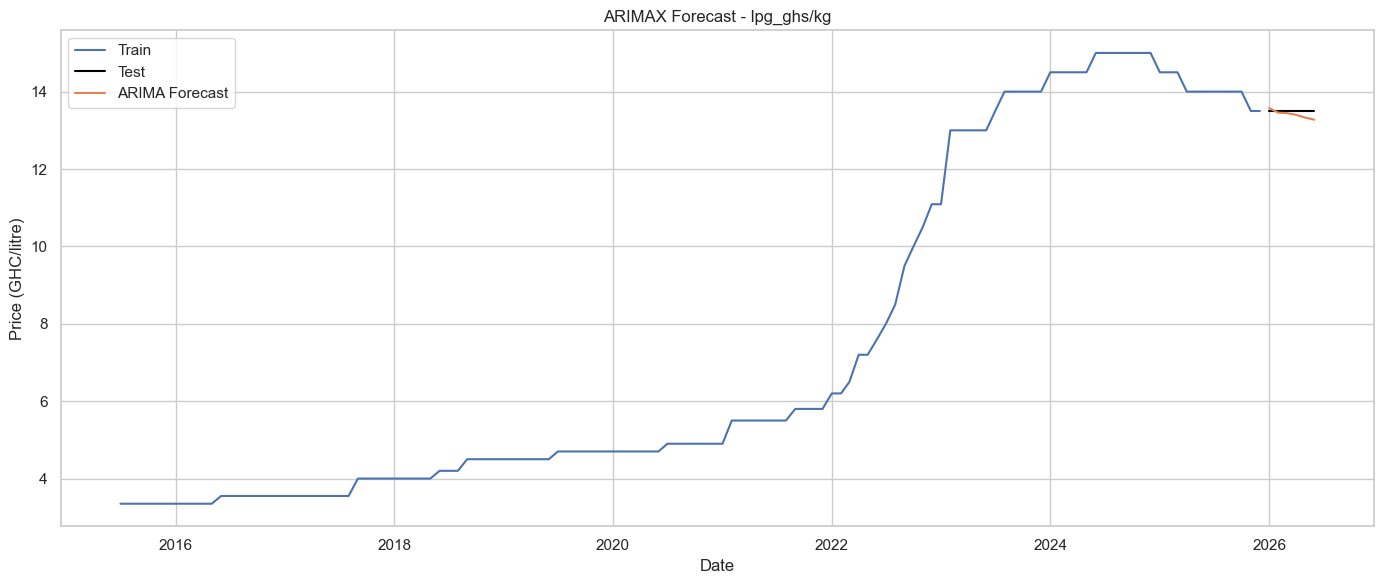

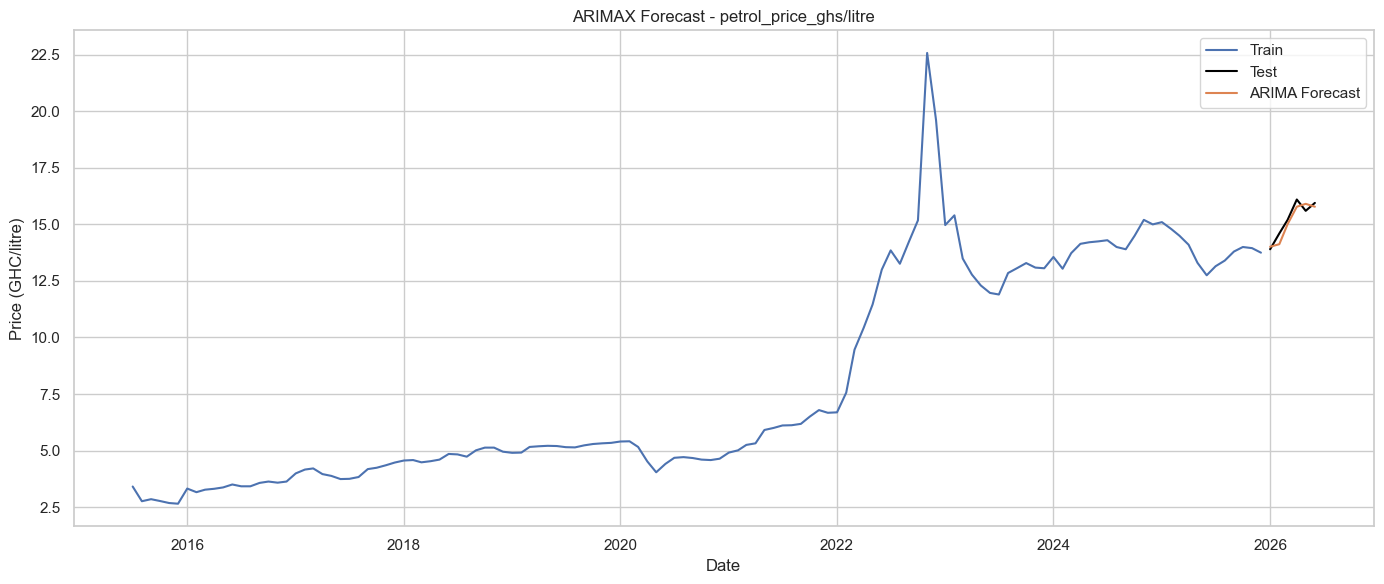

In [232]:
arimax_metrics = pd.DataFrame(arimax_metrics)
arimax_diagnostics = pd.DataFrame(arimax_diagnostics)
print("\nForecast metrics:")
print(arimax_metrics)
print("\nResidual diagnostics:")
print(arimax_diagnostics)

for column in fuel_cols:
    plt.figure(figsize = (14, 6))
    sns.lineplot(x=train.index, y=train[column], label="Train")
    sns.lineplot(x=test.index, y=test[column], color="black", label="Test")
    sns.lineplot(x=arimax_forecast.index, y=arimax_forecast[column], label="ARIMA Forecast")

    plt.title(f"ARIMAX Forecast - {column}")
    plt.xlabel("Date")
    plt.ylabel("Price (GHC/litre)")
    plt.legend()

    safe_col = column.replace("/", "_").replace("\\", "_")
    plt.savefig(
        os.path.join(save_folder, f"ARIMAX_FORCAST_{safe_col}.jpeg"),
        dpi=600,
        bbox_inches="tight"
    )
    plt.tight_layout()
    plt.show()

## **fitting VAR model on TEST data**